# 05 국제선 목적지 수요 예측

> 국제선 수요를 예측해 다음 연도 프로모션 타겟 목적지와 시기를 선정한다.

이 노트북은 목적지별 월간 여객 수요를 예측하고, 정확도를 평가해 프로모션 타겟 후보와 시기를 도출한다. 각 절은 분석 방법과 결과를 먼저 보여준 뒤, 마지막에 해석과 결론을 제시한다.

## 0. 개요·데이터 범위

- **분석 목적**: 목적지별 월간 국제선 수요를 예측해 프로모션을 먼저 검토할 목적지와 시기를 좁힌다.
- **원자료 범위**: 2023년 1월–2026년 7월 국제선 월간 여객 수요다.
- **분석 단위**: 목적지 × 월이다. 항공사 축은 04 §5에서 정리한 이유로 제외한다.
- **데이터 보존**: 상류 뷰(02)와 원본 데이터는 수정하지 않는다.
- **목적지 이름**: 본문은 익숙한 도시·공항 이름을 사용한다. 코드 출력표에는 기존 DB 표기가 그대로 보일 수 있다. 예: 삿포로(DB 표기: 삿보로), 타이베이(DB 표기: 타이페이).

### 분석 기간을 어떻게 나눴나

데이터는 섞지 않고 각 기준월까지 공개된 과거 자료만 사용한다.

| 구분 | 역할 | 예측 기준월 | 예측에 사용할 수 있는 과거자료 | 정답으로 확인하는 기간 |
|---|---|---|---|---|
| 2025년 롤링 Validation | 후보 구조·변수·파라미터를 반복 비교한다 | 2025년 1월–7월 | 2023년 1월부터 각 기준월까지 누적된 자료 | 2025년 2월–12월 |
| 2026년 고정 Test | Validation에서 확정한 B1+Ridge 한 모델만 평가한다 | 2025년 8월–2026년 6월 | 각 기준월까지 확인된 자료. Ridge는 최근 3개 대상월의 오차만 학습 | 2026년 1월–7월 |
| 최종 B1+Ridge 예측 | 확정 모델로 미래 수요를 만든다 | 2026년 7월 | 2023년 1월–2026년 7월 중 규칙상 사용 가능한 과거 자료 | 2026년 8월–12월, 아직 정답 없음 |

---

In [1]:
from pathlib import Path
import os, re, sys
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
load_dotenv(ROOT / '.env')
sys.path.insert(0, str(ROOT / 'scripts'))
import feature_layer as fl                      # as-of-origin 피처 레이어(누수 통제)

PLOTLY_TEMPLATE = 'plotly_white'

SQL_FILE = ROOT / 'sql' / '05_demand_forecast.sql'
LEGACY_HOLDOUT = ROOT / 'data' / 'legacy_holdout_2026.csv'

db = dict(host=os.getenv('DB_HOST'), port=int(os.getenv('DB_PORT', '3306')),
          database=os.getenv('DB_NAME'), username=os.getenv('DB_USER'), password=os.getenv('DB_PASSWORD'))
engine = create_engine(URL.create('mysql+pymysql', **db), pool_pre_ping=True, future=True)

def load_named_queries(path):
    t = path.read_text(encoding='utf-8')
    m = list(re.finditer(r'^-- name: ([a-z0-9_]+)\s*$', t, flags=re.MULTILINE))
    return {x.group(1): t[x.end(): m[i+1].start() if i+1 < len(m) else len(t)].strip().rstrip(';')
            for i, x in enumerate(m)}
SQL = load_named_queries(SQL_FILE)
def query(name): return pd.read_sql(text(SQL[name]), engine)
def execute_ddl(name):
    with engine.begin() as c: c.execute(text(SQL[name]))

# 05가 소유한 뷰를 매 실행 시 멱등적으로 생성한다.
DDL_NAMES = [
    'create_v_model_destination_monthly_all',
    'create_v_demand_destination_profile',
]
missing_ddl = [name for name in DDL_NAMES if name not in SQL]
assert not missing_ddl, f'05 DDL 누락: {missing_ddl}'
for ddl_name in DDL_NAMES:
    execute_ddl(ddl_name)
print('05 모델링 뷰 생성 완료:', ', '.join(DDL_NAMES))

# 레거시 3개월 블록 홀드아웃 기준값(참고): LGBM 0.122 / mean_naive 0.138 / seasonal_naive 0.159


05 모델링 뷰 생성 완료: create_v_model_destination_monthly_all, create_v_demand_destination_profile


## 1. 레거시 예측 진단 (설계 근거)

이 절에서는 기존 3개월 단위 예측에서 LGBM, 최근평균, 전년동월 방식의 오차를 같은 기준으로 비교한다. WAPE는 실제 여객량 대비 예측 오차의 비율이며 낮을수록 좋다. 아래 표를 먼저 확인한 뒤, 표 아래에서 이번 분석의 설계 방향을 정리한다.

In [2]:
# 레거시 홀드아웃 오차 분해 (Stage 1 재현)
h = pd.read_csv(LEGACY_HOLDOUT)
A = 'actual_passengers_next_3m'
MODELS = {'LGBM': 'predicted_passengers_next_3m', 'mean_naive': 'mean_naive_prediction',
          'seasonal_naive': 'seasonal_naive_prediction'}
def wape(df, pred, actual=A): return (df[pred] - df[actual]).abs().sum() / df[actual].sum()

legacy_overall = pd.Series({m: wape(h, c) for m, c in MODELS.items()}, name='holdout_WAPE')
display(legacy_overall.to_frame())

# 레거시 파일은 이번 월 단위 재설계의 비교 기준값으로만 사용한다.
# 모델 선택에 필요한 전체 WAPE 비교는 위 표로 확정했다.


,holdout_WAPE
LGBM,0.122099
mean_naive,0.137964
seasonal_naive,0.158979


### 결과 해석과 결론

LGBM WAPE는 **12.21%**, 최근평균은 13.80%, 전년동월은 15.90%다. LGBM이 가장 좋지만 최근평균과의 차이는 1.59%p에 그쳤다. 또한 3개월 묶음 결과라 월별 프로모션 시기를 고를 수 없다. 따라서 이후 분석은 월 단위 기준선부터 다시 검증한다.

---

## 2. 예측 단위·표본 규칙

월별 관측이 24개월 이상인 목적지만 모델 대상에 포함한다. 기록이 너무 짧으면 한 목적지의 계절성과 성장률을 안정적으로 계산하기 어렵기 때문이다. 아래 표는 목적지를 보유한 월 수에 따라 나눈 결과이며, 표 아래에서 실제 모델 대상과 주의점을 설명한다.

In [3]:
bands = query('profile_sample_bands')
display(bands)
profile = pd.read_sql(text('SELECT * FROM v_demand_destination_profile'), engine)
print('유니버스(>=24개월):', int((profile['in_modeling_universe'] == 1).sum()), '목적지')


,sample_band,destinations,passengers,passenger_share_pct
0,ge36,149,152048353.0,97.9
1,24_35,20,1807371.0,1.2
2,12_23,29,937481.0,0.6
3,lt12,88,498668.0,0.3


유니버스(>=24개월): 169 목적지


### 결과 해석과 결론

`ge36`은 36개월 이상, `24_35`는 24–35개월 기록이 있는 목적지다. 모델 대상 **169곳**이 전체 국제선 여객의 **99.1%** 를 차지한다. 다만 `24_35`는 계절 관측이 적으므로 개별 후보 해석 시 `sample_band`를 함께 확인한다.

---

## 3. 월 단위 과거 입력 및 롤링 검증

- **설계**: 예측 기준월을 한 달씩 앞으로 옮기면서, 그달까지 알 수 있었던 자료만으로 다음 1–5개월을 예측했다. 이를 롤링 방식이라고 한다. 시간 순서를 지켜야 하므로 데이터를 무작위로 섞지 않았다.

### 과거 입력(훈련에 해당) 및 검증 롤링 구성

| 검증 차수 | 예측 기준월 | 과거 입력 범위(B1.5는 훈련 범위) | 검증 대상월 |
|---|---|---|---|
| 1 | 2025년 1월 | 2023년 1월–2025년 1월 | 2025년 2월–6월 |
| 2 | 2025년 2월 | 2023년 1월–2025년 2월 | 2025년 3월–7월 |
| 3 | 2025년 3월 | 2023년 1월–2025년 3월 | 2025년 4월–8월 |
| 4 | 2025년 4월 | 2023년 1월–2025년 4월 | 2025년 5월–9월 |
| 5 | 2025년 5월 | 2023년 1월–2025년 5월 | 2025년 6월–10월 |
| 6 | 2025년 6월 | 2023년 1월–2025년 6월 | 2025년 7월–11월 |
| 7 | 2025년 7월 | 2023년 1월–2025년 7월 | 2025년 8월–12월 |

각 차수는 기준월까지의 자료만 사용한다. B1은 이 자료로 값을 계산하고, B1.5 이후 모델은 정답이 확인된 과거 행을 훈련에 사용한다.

- **입력값**: 전년동월, 최근 3개월과 전년 동기, 이전 완전연도의 계절 패턴이다.
- **2025년부터 검증한 이유**: 2023년은 회복 반등기라 정상적인 계절·성장 기준으로 쓰기 어려웠다.
- **모델 차이**: B0·B1은 계산식, B1.5 이후는 기준월마다 다시 훈련하는 모델이다.

### 실제 입력 데이터 확인

아래에서 원자료의 `shape`·`head()`·`info()`·`describe()`와 미래정보 누수 여부를 확인한다.

In [4]:
panel = fl.load_panel(engine)

# 실제 모델 입력 원자료의 구조와 분포 확인
print('원자료 shape:', panel.shape)
print('원자료 기간:', panel['period'].min(), '–', panel['period'].max(),
      '| 목적지:', panel['dest'].nunique())
display(panel[['dest', 'period', 'passengers', 'operations', 'oac']].head(10))


원자료 shape: (7825, 5)
원자료 기간: 2023-01 – 2026-07 | 목적지: 286


,dest,period,passengers,operations,oac
0,간사이,2023-01,201845.0,1046.0,6.0
1,과달라하라,2023-01,0.0,12.0,1.0
2,괌,2023-01,41882.0,226.0,2.0
3,광저우,2023-01,2343.0,43.0,1.0
4,구마모도,2023-01,1785.0,12.0,1.0
5,그린빌스파르탄버그,2023-01,0.0,5.0,1.0
6,껀터,2023-01,2200.0,13.0,1.0
7,나고야,2023-01,17353.0,127.0,1.0
8,나트랑캄란,2023-01,54258.0,298.0,3.0
9,난징,2023-01,6247.0,27.0,1.0


In [5]:
# 원자료 열 구조·자료형·결측 여부
panel.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7825 entries, 0 to 7824
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype    
---  ------      --------------  -----    
 0   dest        7825 non-null   object   
 1   period      7825 non-null   period[M]
 2   passengers  7825 non-null   float64  
 3   operations  7825 non-null   float64  
 4   oac         7825 non-null   float64  
dtypes: float64(3), object(1), period[M](1)
memory usage: 305.8+ KB


In [6]:
# 원자료 수치형 변수 기술통계
panel_describe = panel[['passengers', 'operations', 'oac']].describe().T.round(2)
display(panel_describe)


,count,mean,std,min,25%,50%,75%,max
passengers,7825.0,19845.61,40514.65,0.0,1313.0,6378.0,18783.0,383656.0
operations,7825.0,115.88,219.08,0.0,14.0,40.0,115.0,2154.0
oac,7825.0,1.46,1.06,0.0,1.0,1.0,2.0,7.0


In [7]:
# 모델 대상과 2025년 롤링 검증용 피처 생성
universe = fl.load_universe(engine)
grids = fl.build_grids(panel)
feat = fl.build_features(grids, universe, fl.VALIDATION_ORIGINS)
print('피처 shape:', feat.shape, '| 목적지', feat['dest'].nunique(),
      '| 기준월×horizon', feat.groupby(['origin','horizon']).ngroups)
print('계절지수 자기산출 비율: %.1f%%' % (feat['seasonal_index_own'].mean()*100))
print('누수 검증:', fl.leakage_checks(feat))


피처 shape: (5855, 30) | 목적지 169 | 기준월×horizon 35
계절지수 자기산출 비율: 84.9%
누수 검증: {'rows': 5855, 'max_feat<=origin': True, 'origin<target': True, 'target<=panel_end': True, 'no_future_ref': True}


In [8]:
# 검증 대상월별 기준월·horizon 커버리지
cover = (feat.groupby('tmon').agg(
    rows=('dest','size'), origins=('origin','nunique'),
    horizons=('horizon', lambda s: sorted(set(s)))))
display(cover)


,rows,origins,horizons
tmon,,,
2,166,1,[1]
3,332,2,"[1, 2]"
4,498,3,"[1, 2, 3]"
5,665,4,"[1, 2, 3, 4]"
6,833,5,"[1, 2, 3, 4, 5]"
7,836,5,"[1, 2, 3, 4, 5]"
8,839,5,"[1, 2, 3, 4, 5]"
9,673,4,"[2, 3, 4, 5]"
10,506,3,"[3, 4, 5]"


### 결과 해석과 결론

원자료는 **7,825행×5열**, 2023년 1월–2026년 7월의 286개 목적지 자료다. 한 행은 `목적지×월`이며 여객 수·운항 횟수·출발 공항 수를 담는다. 월별 여객 수 평균이 중앙값보다 커 목적지 규모 차이가 크므로 성능은 여객량을 반영하는 WAPE로 평가한다.

24개월 이상 기록이 있는 169개 목적지만 사용한 롤링 피처는 **5,855행×30열**이다. 누수 검사 네 항목은 모두 `True`로, 기준월 이후 자료를 사용하지 않았다. 11·12월은 검증 반복이 적어 최종 결과에서 `저신뢰`로 표시한다.

---

## 4. 계절지수·성장계수 설계

- **계절지수**: 목적지마다 어느 달에 수요가 높고 낮은지를 나타낸다. 2023년은 회복기라 계절 모양 계산에서 빼고, 2024년 이후의 완전한 연도만 사용한다. 목적지 자체 자료가 부족하면 전체 목적지의 평균 계절 모양을 대신 쓴다.
- **성장계수**: 최근 3개월 수요가 전년 같은 3개월보다 얼마나 늘었는지를 나타낸다. 2023년이 비교 기준에 들어가면 성장계수를 1, 즉 변화 없음으로 둔다. 그해의 회복 반등을 정상 성장으로 오해하지 않기 위해서다.

아래에서 성장률 분포, 2023년 포함 행, 극단값 제한과 계절유형 안정성을 확인한다.

In [9]:
# 성장계수 진단: 기존 3개월 YoY의 2023 분모 영향과 안전 규칙
u = feat.drop_duplicates(['dest','origin']).copy()
display(u.groupby('origin')['growth_raw_legacy'].agg(n='count', median='median', mean='mean',
        p10=lambda s: s.quantile(.10), p90=lambda s: s.quantile(.90)).round(3))
unsafe = u['growth_denominator_has_2023']
print('2023 분모 (dest, origin): %d/%d; growth=1 중립 폴백 적용' % (unsafe.sum(), len(u)))
safe = u[u['growth_eligible']].copy()
clipped = (safe['growth_raw'] < fl.GROWTH_CLIP[0]) | (safe['growth_raw'] > fl.GROWTH_CLIP[1])
print('안전 origin의 클리핑 히트: %d/%d (%.1f%%)' % (clipped.sum(), len(safe), clipped.mean()*100))

med = safe.groupby('origin')['growth_raw'].median()
f = feat[feat['growth_eligible'] & feat['seasonal_naive_pred'].notna() & (feat['seasonal_naive_pred'] > 0)].copy()
f['med'] = f['origin'].map(med)
f['tq'] = f['tmon'].apply(lambda m: 'Q1' if m<=3 else ('Q2' if m<=6 else 'H2'))
def net_bias(df, pred): return (pred - df[A0]).sum() / df[A0].sum()
A0 = 'target_passengers'
rows = []
for w in (0.5, 0.75, 1.0):
    gw = f['med']*(1-w) + f['growth_clipped']*w
    pred = f['seasonal_naive_pred'] * gw
    rows.append({'w': w, '전체': net_bias(f, pred),
                 'Q2': net_bias(f[f.tq=='Q2'], pred[f.tq=='Q2']),
                 'H2': net_bias(f[f.tq=='H2'], pred[f.tq=='H2'])})
display(pd.DataFrame(rows).set_index('w').round(3))

# 라벨 불안정성
display(query('seasonal_label_agreement'))
# 계절형 라벨은 설명용이며 모델 입력이 아니므로 추가 임계값 튜닝은 하지 않는다.


,n,median,mean,p10,p90
origin,,,,,
2025-01,139,1.186,1.353,0.901,1.823
2025-02,139,1.090,1.221,0.875,1.649
2025-03,140,1.074,1.192,0.865,1.646
2025-04,141,1.066,1.165,0.809,1.663
2025-05,141,1.091,1.171,0.804,1.663
2025-06,142,1.069,1.142,0.758,1.607
2025-07,143,1.068,1.116,0.765,1.473


2023 분모 (dest, origin): 332/1171; growth=1 중립 폴백 적용
안전 origin의 클리핑 히트: 100/839 (11.9%)


,전체,Q2,H2
w,,,
0.50,0.022,0.022,0.022
0.75,0.020,0.021,0.020
1.00,0.018,0.021,0.017


,scope_label,comparable,same,agreement_pct
0,all,162.0,117.0,72.2
1,modeling_universe,162.0,117.0,72.2


### 결과 해석과 결론

성장률 비교 기준에 2023년이 포함된 조합은 **332개**이며, 회복 반등 때문에 과대예측을 만들 수 있다. 이 경우 성장계수를 1로 두어 전년동월 수준으로 돌아간다. 나머지 조합도 극단값을 제한한다.

계절유형 일치율은 72.2%이므로 `겨울형·여름형`은 설명에만 쓰고, 예측에는 월별 계절지수를 사용한다. 즉 2023년은 원자료에는 남기되 정상 계절·성장 기준에서는 제외한다.

---

## 5. 모델 사다리

쉬운 모델부터 비교하고 검증 WAPE가 실제로 낮아질 때만 복잡도를 높인다.

**모델별 역할**
- **B0**: 전년동월·최근평균처럼 누구나 이해할 수 있는 기준선이다.
- **B1**: B0에 성장률 또는 계절 정보를 더한 개선안이다.
- **B1.5/B2**: Ridge와 부스팅 트리처럼 더 복잡한 후보이며, B1보다 확실히 나을 때만 채택한다.

**채택 기준:** 직전 모델보다 검증 WAPE가 **5% 이상 낮고** 월·계절 편향이 악화되지 않아야 한다. 최종 Test는 확정 모델 하나만 평가하며 재튜닝에 쓰지 않는다.

---

### 5.0 B0/B1 편향 분해 (기저 vs 성장계수)

전년동월 수요 자체가 문제인지, 여기에 곱한 성장계수가 문제인지 분리해 확인한다. `bias`가 양수면 실제보다 크게 예측했고, 음수면 작게 예측했다는 뜻이다. 아래 표에서는 전체 기간뿐 아니라 Q1·Q2·하반기의 방향이 같은지도 비교한다.

In [10]:
# 5.0 편향 분해: 전년동월 단독 / 최근평균 단독 / B1
base = feat[feat['seasonal_naive_pred'].notna() & (feat['seasonal_naive_pred'] > 0)].copy()
base['tq'] = base['tmon'].apply(lambda m: 'Q1' if m<=3 else ('Q2' if m<=6 else 'H2'))
preds = {
    'B0a_전년동월단독': base['seasonal_naive_pred'],
    'B0b_최근평균단독': base['mean_naive_pred'],
    'B1_전년동월x성장': base['seasonal_naive_pred'] * base['growth_damped'],
}
out = []
for name, p in preds.items():
    row = {'model': name}
    for seg in ('전체','Q1','Q2','H2'):
        d = base if seg=='전체' else base[base.tq==seg]
        pp = p if seg=='전체' else p[base.tq==seg]
        row[seg+'_bias'] = (pp.sum() - d['target_passengers'].sum()) / d['target_passengers'].sum()
    out.append(row)
display(pd.DataFrame(out).set_index('model').round(3))


,전체_bias,Q1_bias,Q2_bias,H2_bias
model,,,,
B0a_전년동월단독,-0.045,-0.043,-0.050,-0.043
B0b_최근평균단독,-0.013,0.112,0.036,-0.057
B1_전년동월x성장,0.002,-0.043,-0.015,0.017


#### 결과 해석과 결론

전년동월 편향은 전 구간 −4.3%~−5.0%로 안정적이지만, 최근평균은 Q1 +11.2%로 계절 전환에 취약하다. 안전 규칙을 적용한 B1의 전체 편향은 +0.2%다. 따라서 전년동월을 기저로 유지하고, 성장률 분모에 2023년이 포함될 때만 성장계수를 1로 둔다.

### 5.1 B0 — 최근평균 / 전년동월 (하한선)

B0는 별도 학습 없이 계산하는 **단순 기준선**이다.

#### 기준월과 horizon

**기준월(origin)** 은 예측 시점, **horizon(h)** 은 몇 개월 뒤인지다. 기준월이 2025년 7월이면 h1은 8월, h5는 12월이다.

#### 두 B0 방식

- **최근평균**: 최근 3개월 평균을 h1–h5에 동일하게 적용한다. 최근 수준은 반영하지만 계절 변화는 놓칠 수 있다.
- **전년동월**: 예측월의 1년 전 같은 목적지 수요를 사용한다. 예: 2025년 8월은 2024년 8월 수요로 예측한다.

#### 롤링 검증 범위

7개 기준월에서 h1–h5를 예측해 `7×5=35개` 시점 조합을 평가한다. 상세 월 구성은 3절의 롤링 표와 같다.

In [11]:
# B0 예측 + WAPE. seasonal_naive=전년동월, mean_naive=최근3개월 평균
def wape_m(df, pred_col, actual='target_passengers'):
    return (df[pred_col] - df[actual]).abs().sum() / df[actual].sum()
b0 = feat.copy()
b0['pred_mean_naive'] = b0['mean_naive_pred']
b0['pred_seasonal_naive'] = b0['seasonal_naive_pred']
def summary_metrics(df, pred_col, actual='target_passengers'):
    return pd.Series({'WAPE': wape_m(df, pred_col, actual),
                      '순편향': (df[pred_col].sum()-df[actual].sum())/df[actual].sum()})
b0_summary = pd.DataFrame({
    '최근평균': summary_metrics(b0, 'pred_mean_naive'),
    '전년동월': summary_metrics(b0, 'pred_seasonal_naive'),
}).T
display(b0_summary.round(4))


,WAPE,순편향
최근평균,0.1572,-0.0129
전년동월,0.1409,-0.0466


In [12]:
# B0 예측거리별 WAPE
b0_horizon = pd.DataFrame({
    '최근평균': b0.groupby('horizon').apply(
        lambda x: wape_m(x, 'pred_mean_naive'), include_groups=False),
    '전년동월': b0.groupby('horizon').apply(
        lambda x: wape_m(x, 'pred_seasonal_naive'), include_groups=False),
})
display(b0_horizon.round(4))


,최근평균,전년동월
horizon,,
1,0.1279,0.1395
2,0.1518,0.1417
3,0.1606,0.1410
4,0.1685,0.1408
5,0.1759,0.1415


#### 출력 결과를 읽는 법

WAPE는 절대오차 합을 실제수요 합으로 나눈 통합 오차율이다. 최근평균은 15.72%, 전년동월은 14.09%다. **순편향**은 음수면 과소, 양수면 과대예측이며 두 방식 모두 전체 수요를 조금 낮게 봤다.

#### horizon별 표를 읽는 법

각 행은 같은 horizon의 7개 기준월과 전체 목적지를 합친 결과다.

| 예측거리 | 최근평균 | 전년동월 | 해당 horizon의 검증 대상 | 더 정확한 방식 |
|---|---:|---:|---|---|
| h1: 1개월 뒤 | 12.79% | 13.95% | 2025년 2월–8월 | 최근평균 |
| h2: 2개월 뒤 | 15.18% | 14.17% | 2025년 3월–9월 | 전년동월 |
| h3: 3개월 뒤 | 16.06% | 14.10% | 2025년 4월–10월 | 전년동월 |
| h4: 4개월 뒤 | 16.85% | 14.08% | 2025년 5월–11월 | 전년동월 |
| h5: 5개월 뒤 | 17.59% | 14.15% | 2025년 6월–12월 | 전년동월 |

#### B0 결론

최근평균은 거리가 멀수록 나빠지지만 전년동월은 약 14%로 일정하다. 따라서 **전년동월을 B0 기준선**으로 선택한다.

---

### 5.2 B1 — 전년동월×성장계수 · 계절지수×수준

B1도 별도 학습 없이 두 계산식을 비교한다.

#### 먼저 알아둘 성장계수 용어

- **목적지 성장률**: 최근 3개월 합계 ÷ 전년도 같은 3개월 합계다. 1.20은 20% 성장을 뜻한다.
- **전체 목적지 중앙값**: 목적지별 성장률의 가운데 값으로, 극단값에 덜 흔들리는 시장 흐름이다.
- **최종 성장계수**: 제한한 목적지 성장률 75%와 전체 중앙값 25%를 합친 값이다.

#### B1 후보 1. 전년동월 × 안전한 성장계수

- `목적지 성장률 = 최근 3개월 수요 합계 ÷ 전년도 같은 3개월 수요 합계`
- `최종 성장계수 = 제한한 목적지 성장률 × 0.75 + 전체 목적지 중앙값 × 0.25`
- `B1 예측 = B0 전년동월 수요 × 최종 성장계수`

예: 전년동월 10만 명, 목적지 성장률 1.20, 중앙값 1.08이면 성장계수는 1.17, 예측은 11만7천 명이다.

#### 2023년 회복기 안전장치

비교 구간에 2023년이 포함되면 성장계수를 1로 둔다. 목적지 성장률을 계산할 수 없으면 전체 중앙값을 사용한다.

#### B1 후보 2. 계절지수 × 최근 수준

최근 3개월에서 계절 효과를 제거한 기본 수준에 목표월 계절지수를 곱한다.

1. `각 최근 월의 탈계절 수준 = 해당 월 실제 수요 ÷ 해당 월 계절지수`
2. `최근 기본수준 = 최근 3개월 탈계절 수준의 평균`
3. `B1 계절지수 예측 = 최근 기본수준 × 예측 대상월 계절지수`

예: 탈계절 수준이 10만 명이고 8월 계절지수가 1.30이면 13만 명으로 예측한다.

#### 목적지 성장률·최종 성장계수·계절지수를 모두 곱하지 않는 이유

B0 전년동월에 계절성이 이미 포함되어 있어 성장계수와 계절지수를 모두 곱하면 효과가 중복될 수 있다. 따라서 두 후보를 분리해 비교한다.

In [13]:
# B1 변형 — 2023 분모 origin은 feature_layer에서 growth=1로 중립화
b1 = feat.copy()
b1['pred_b1_growth'] = b1['seasonal_naive_pred'] * b1['growth_damped']          # (i) 전년동월×성장계수
# (ii) 최근 3개월을 각 관측월 계절지수로 나눈 탈계절 수준 × 타깃월 계절지수
b1['pred_b1_index'] = b1['seasonal_level_ma_3'] * b1['seasonal_index_target']
assert b1[['pred_b1_growth', 'pred_b1_index']].notna().all().all(), 'B1 예측 결측 존재'
b1_summary = pd.DataFrame({
    '전년동월×성장': summary_metrics(b1, 'pred_b1_growth'),
    '계절지수×수준': summary_metrics(b1, 'pred_b1_index'),
}).T
b1_summary['전년동월 대비 상대개선'] = 1 - b1_summary['WAPE'] / b0_summary.loc['전년동월', 'WAPE']
display(b1_summary.round(4))


,WAPE,순편향,전년동월 대비 상대개선
전년동월×성장,0.1184,0.0002,0.1595
계절지수×수준,0.1184,0.0239,0.1596


In [14]:
# B1 후보 1 전체 계산 DataFrame: 전년동월 × 성장계수
b1_growth_view = b1[[
    'dest', 'origin', 'horizon', 'target_period',
    'seasonal_naive_pred', 'growth_raw', 'growth_clipped',
    'growth_damped', 'growth_denominator_has_2023', 'growth_fallback',
    'pred_b1_growth', 'target_passengers'
]].rename(columns={
    'dest': '목적지', 'origin': '기준월', 'horizon': '예측거리',
    'target_period': '예측월', 'seasonal_naive_pred': 'B0_전년동월',
    'growth_raw': '목적지_성장률', 'growth_clipped': '제한후_성장률',
    'growth_damped': '최종_성장계수',
    'growth_denominator_has_2023': '분모_2023포함',
    'growth_fallback': '성장률_대체사유',
    'pred_b1_growth': '후보1_예측', 'target_passengers': '실제수요'
})
print('후보 1 전체 계산 DataFrame shape:', b1_growth_view.shape)
display(b1_growth_view.round(3))


후보 1 전체 계산 DataFrame shape: (5855, 12)


,목적지,기준월,예측거리,예측월,B0_전년동월,목적지_성장률,제한후_성장률,최종_성장계수,분모_2023포함,성장률_대체사유,후보1_예측,실제수요
0,간사이,2025-01,1,2025-02,286775.0,NaN,1.000,1.000,True,pre_2024_denominator,286775.0,283173.0
1,간사이,2025-01,2,2025-03,314073.0,NaN,1.000,1.000,True,pre_2024_denominator,314073.0,308770.0
2,간사이,2025-01,3,2025-04,273263.0,NaN,1.000,1.000,True,pre_2024_denominator,273263.0,285882.0
3,간사이,2025-01,4,2025-05,298166.0,NaN,1.000,1.000,True,pre_2024_denominator,298166.0,303916.0
4,간사이,2025-01,5,2025-06,281147.0,NaN,1.000,1.000,True,pre_2024_denominator,281147.0,277776.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5850,어저우화후,2025-07,1,2025-08,0.0,NaN,1.068,1.068,False,cross_sectional_median,0.0,0.0
5851,어저우화후,2025-07,2,2025-09,0.0,NaN,1.068,1.068,False,cross_sectional_median,0.0,0.0
5852,어저우화후,2025-07,3,2025-10,0.0,NaN,1.068,1.068,False,cross_sectional_median,0.0,0.0
5853,어저우화후,2025-07,4,2025-11,0.0,NaN,1.068,1.068,False,cross_sectional_median,0.0,0.0


In [15]:
# B1 후보 2 전체 계산 DataFrame: 계절지수 × 최근 수준
b1_index_view = b1[[
    'dest', 'origin', 'horizon', 'target_period',
    'seasonal_level_ma_3', 'seasonal_index_target',
    'seasonal_index_own', 'pred_b1_index', 'target_passengers'
]].rename(columns={
    'dest': '목적지', 'origin': '기준월', 'horizon': '예측거리',
    'target_period': '예측월', 'seasonal_level_ma_3': '최근_탈계절수준',
    'seasonal_index_target': '목표월_계절지수',
    'seasonal_index_own': '자체_계절지수',
    'pred_b1_index': '후보2_예측', 'target_passengers': '실제수요'
})
print('후보 2 전체 계산 DataFrame shape:', b1_index_view.shape)
display(b1_index_view.round(3))


후보 2 전체 계산 DataFrame shape: (5855, 9)


,목적지,기준월,예측거리,예측월,최근_탈계절수준,목표월_계절지수,자체_계절지수,후보2_예측,실제수요
0,간사이,2025-01,1,2025-02,298497.206,0.983,True,293504.063,283173.0
1,간사이,2025-01,2,2025-03,298497.206,1.077,True,321442.600,308770.0
2,간사이,2025-01,3,2025-04,298497.206,0.937,True,279675.010,285882.0
3,간사이,2025-01,4,2025-05,298497.206,1.022,True,305162.349,303916.0
4,간사이,2025-01,5,2025-06,298497.206,0.964,True,287744.005,277776.0
...,...,...,...,...,...,...,...,...,...
5850,어저우화후,2025-07,1,2025-08,0.000,1.081,False,0.000,0.0
5851,어저우화후,2025-07,2,2025-09,0.000,0.979,False,0.000,0.0
5852,어저우화후,2025-07,3,2025-10,0.000,1.076,False,0.000,0.0
5853,어저우화후,2025-07,4,2025-11,0.000,0.944,False,0.000,0.0


In [16]:
# 실제 데이터 계산 예시 1: 간사이, 기준월 2025년 7월, 후보 1
b1_example = (b1[(b1['dest'] == '간사이') &
                 (b1['origin'] == pd.Period('2025-07', freq='M'))]
              .sort_values('horizon').copy())
candidate1_example = b1_example[[
    'target_period', 'seasonal_naive_pred', 'growth_raw', 'growth_damped',
    'pred_b1_growth', 'target_passengers'
]].rename(columns={
    'target_period': '예측월', 'seasonal_naive_pred': 'B0_전년동월',
    'growth_raw': '목적지_성장률', 'growth_damped': '최종_성장계수',
    'pred_b1_growth': '후보1_예측', 'target_passengers': '실제수요'
})
candidate1_example['오차'] = candidate1_example['후보1_예측'] - candidate1_example['실제수요']
candidate1_example['절대오차'] = candidate1_example['오차'].abs()
candidate1_example['행별_APE'] = (
    candidate1_example['절대오차'] / candidate1_example['실제수요']
)
display(candidate1_example.round(3))


,예측월,B0_전년동월,목적지_성장률,최종_성장계수,후보1_예측,실제수요,오차,절대오차,행별_APE
5010,2025-08,250826.0,0.976,0.999,250604.634,269618.0,-19013.366,19013.366,0.071
5011,2025-09,273192.0,0.976,0.999,272950.895,285376.0,-12425.105,12425.105,0.044
5012,2025-10,307436.0,0.976,0.999,307164.673,315375.0,-8210.327,8210.327,0.026
5013,2025-11,319023.0,0.976,0.999,318741.447,347246.0,-28504.553,28504.553,0.082
5014,2025-12,317043.0,0.976,0.999,316763.194,362453.0,-45689.806,45689.806,0.126


In [17]:
# 간사이 후보 1 예시의 2025년 8월–12월 통합 WAPE
candidate1_example_wape = pd.DataFrame([{
    '목적지': '간사이',
    '기준월': '2025년 7월',
    '평가기간': '2025년 8월–12월',
    '절대오차합': candidate1_example['절대오차'].sum(),
    '실제수요합': candidate1_example['실제수요'].sum(),
    '통합_WAPE': (candidate1_example['절대오차'].sum() /
                 candidate1_example['실제수요'].sum())
}])
display(candidate1_example_wape.round(4))


,목적지,기준월,평가기간,절대오차합,실제수요합,통합_WAPE
0,간사이,2025년 7월,2025년 8월–12월,113843.1565,1580068.0,0.072


In [18]:
# 실제 데이터 계산 예시 2: 간사이, 기준월 2025년 7월, 후보 2
candidate2_example = b1_example[[
    'target_period', 'seasonal_level_ma_3', 'seasonal_index_target',
    'pred_b1_index', 'target_passengers'
]].rename(columns={
    'target_period': '예측월', 'seasonal_level_ma_3': '최근_탈계절수준',
    'seasonal_index_target': '목표월_계절지수',
    'pred_b1_index': '후보2_예측', 'target_passengers': '실제수요'
})
display(candidate2_example.round(3))


,예측월,최근_탈계절수준,목표월_계절지수,후보2_예측,실제수요
5010,2025-08,284390.407,0.860,244579.501,269618.0
5011,2025-09,284390.407,0.937,266388.505,285376.0
5012,2025-10,284390.407,1.054,299779.702,315375.0
5013,2025-11,284390.407,1.094,311078.143,347246.0
5014,2025-12,284390.407,1.087,309147.452,362453.0


#### 출력 결과를 읽는 법

두 후보 모두 WAPE 11.84%로 B0 14.09%보다 약 15.95% 개선됐다.

| B1 후보 | 전체 WAPE | 순편향 | B0 전년동월 대비 상대개선 |
|---|---:|---:|---:|
| 전년동월×성장 | 11.84% | +0.02% | 15.95% |
| 계절지수×수준 | 11.84% | +2.39% | 15.96% |

전년동월×성장은 순편향이 거의 0이고, 계절지수×수준은 +2.39%로 조금 높게 예측했다.


#### 실제 오사카 간사이 예시를 읽는 법

2025년 7월 오사카 간사이 예시의 최종 성장계수는 0.999다. 8월 B0 250,826명은 약 250,605명으로 조정됐고, 8월–12월 통합 WAPE는 7.2%다. 이는 한 목적지 예시이므로 전체 WAPE와 직접 비교하지 않는다.

#### 왜 이 표만으로 최종 B1을 고르지 않나

전체 WAPE는 같지만 전년동월×성장은 h1–h5를 모두 통과했고, 계절지수×수준은 h5에서 B0보다 나빴다.

#### B1 단계 결론

최종 B1은 **전년동월×성장계수**다. Validation WAPE는 B0 14.09%에서 11.84%로 낮아졌으며, 이후 학습 모델이 넘어야 할 기준으로 사용한다.

---

### 5.3 B1.5 — Ridge 선형회귀

> **진행 범위:** Train + Validation · Test 미실행

B1.5는 여러 과거 수요 변수와 실제 수요의 관계를 Ridge가 직접 학습한다.

#### Ridge 선형회귀란

Ridge는 선형회귀 계수가 지나치게 커지지 않도록 벌점을 주는 모델이다. 비슷한 lag·이동평균 변수가 많을 때 흔들림을 줄이며 `alpha=1.0`을 사용한다.

#### B1.5가 사용하는 입력 변수

- **lag_1·lag_3·lag_12**: 기준월, 2개월 전, 11개월 전 수요다.
- **ma_3·ma_12**: 기준월을 포함한 최근 3개월·12개월 평균 수요다.
- **seasonal_index_target**: 예측 대상월의 계절지수다.
- **growth_damped**: B1에서 사용한 안전한 최종 성장계수다.
- **horizon**: 기준월에서 몇 개월 뒤를 예측하는지다.
- **목표 월 표시값**: 월별 차이를 학습하는 0·1 변수다.

수요 변수는 `log(1+x)`로 변환하고 훈련자료 기준으로 표준화한다.

#### 실제 훈련과 롤링 검증 과정

1. 기준월까지 실제 수요가 확인된 과거 행만 훈련한다.
2. 같은 기준월의 h1–h5를 검증한다.
3. 기준월이 이동하면 새 정답을 추가해 Ridge와 스케일러를 다시 적합한다.

즉 7개 기준월마다 다시 학습하는 **walk-forward 모델**이며 미래 실제값은 사용하지 않는다.

In [19]:
# B1.5 선형회귀 (walk-forward Ridge). 폴드별 학습 구간(target_period <= origin)에서만 적합.
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

allf = fl.build_features(grids, universe, pd.period_range('2024-06', '2025-07', freq='M'))  # 학습 풀
B15_NUM = ['lag_1','lag_3','lag_12','ma_3','ma_12','seasonal_index_target','growth_damped','horizon']
B15_LOG = ['lag_1','lag_3','lag_12','ma_3','ma_12']

def _b15_Xy(df):
    X = df[B15_NUM].copy()
    for c in B15_LOG:
        X[c] = np.log1p(X[c].clip(lower=0))
    md = pd.get_dummies(df['target_month'].astype(int), prefix='m').reindex(
        columns=[f'm_{m}' for m in range(2, 13)], fill_value=0)   # m_1 기준월
    X = pd.concat([X.reset_index(drop=True), md.reset_index(drop=True)], axis=1)
    return X, np.log1p(df['target_passengers'].to_numpy())

_parts = []
_fold_rows = []
for o in fl.VALIDATION_ORIGINS:
    tr, te = allf[allf['target_period'] <= o], allf[allf['origin'] == o]   # 누수 통제: 관측된 타깃만 학습
    Xtr, ytr = _b15_Xy(tr); Xte, _ = _b15_Xy(te)
    Xte = Xte.reindex(columns=Xtr.columns, fill_value=0)
    sc = StandardScaler().fit(Xtr.values)                                  # 스케일러도 학습 구간만
    mdl = Ridge(alpha=1.0).fit(sc.transform(Xtr.values), ytr)             # 결정적 -> 시드 불필요
    t = te.copy(); t['pred_b15'] = np.clip(
        np.expm1(mdl.predict(sc.transform(Xte.values))), 0, None)
    _parts.append(t)
    _fold_rows.append({
        '기준월': o, '훈련_행수': len(tr),
        '훈련_예측월_시작': tr['target_period'].min(),
        '훈련_예측월_종료': tr['target_period'].max(),
        '검증_행수': len(te),
        '검증_예측월_시작': te['target_period'].min(),
        '검증_예측월_종료': te['target_period'].max(),
    })
b15 = pd.concat(_parts, ignore_index=True)
b15_folds = pd.DataFrame(_fold_rows)
b15['오차'] = b15['pred_b15'] - b15['target_passengers']
b15['절대오차'] = b15['오차'].abs()
b15['행별_APE'] = np.where(
    b15['target_passengers'] > 0,
    b15['절대오차'] / b15['target_passengers'], np.nan)
b15['tq'] = b15['tmon'].apply(
    lambda m: 'Q1' if m <= 3 else ('Q2' if m <= 6 else 'H2'))

def _W(df, col, actual='target_passengers'):
    return (df[col] - df[actual]).abs().sum() / df[actual].sum()

def _bias_b15(df):
    return ((df['pred_b15'].sum() - df['target_passengers'].sum()) /
            df['target_passengers'].sum())


In [20]:
# B1.5 입력 변수 설명
b15_feature_guide = pd.DataFrame([
    ['lag_1', '기준월 수요', 'log(1+x) 후 표준화'],
    ['lag_3', '기준월에서 두 달 전 수요', 'log(1+x) 후 표준화'],
    ['lag_12', '기준월에서 11개월 전 수요', 'log(1+x) 후 표준화'],
    ['ma_3', '기준월 포함 최근 3개월 평균', 'log(1+x) 후 표준화'],
    ['ma_12', '기준월 포함 최근 12개월 평균', 'log(1+x) 후 표준화'],
    ['seasonal_index_target', '예측 대상월 계절지수', '표준화'],
    ['growth_damped', '안전하게 조정한 최종 성장계수', '표준화'],
    ['horizon', '몇 개월 뒤 예측인지', '표준화'],
    ['m_2–m_12', '예측 대상월 표시값, 1월은 기준', '0 또는 1'],
], columns=['입력변수', '의미', '모델 입력 처리'])
display(b15_feature_guide)


,입력변수,의미,모델 입력 처리
0,lag_1,기준월 수요,log(1+x) 후 표준화
1,lag_3,기준월에서 두 달 전 수요,log(1+x) 후 표준화
2,lag_12,기준월에서 11개월 전 수요,log(1+x) 후 표준화
3,ma_3,기준월 포함 최근 3개월 평균,log(1+x) 후 표준화
4,ma_12,기준월 포함 최근 12개월 평균,log(1+x) 후 표준화
5,seasonal_index_target,예측 대상월 계절지수,표준화
6,growth_damped,안전하게 조정한 최종 성장계수,표준화
7,horizon,몇 개월 뒤 예측인지,표준화
8,m_2–m_12,"예측 대상월 표시값, 1월은 기준",0 또는 1


In [21]:
# 7개 차수별 실제 훈련·검증 범위
display(b15_folds)


,기준월,훈련_행수,훈련_예측월_시작,훈련_예측월_종료,검증_행수,검증_예측월_시작,검증_예측월_종료
0,2025-01,4052,2024-07,2025-01,830,2025-02,2025-06
1,2025-02,4878,2024-07,2025-02,830,2025-03,2025-07
2,2025-03,5706,2024-07,2025-03,830,2025-04,2025-08
3,2025-04,6535,2024-07,2025-04,835,2025-05,2025-09
4,2025-05,7366,2024-07,2025-05,840,2025-06,2025-10
5,2025-06,8199,2024-07,2025-06,845,2025-07,2025-11
6,2025-07,9035,2024-07,2025-07,845,2025-08,2025-12


In [22]:
# B1.5 훈련 후보 풀 전체 DataFrame
b15_training_pool = allf[[
    'dest', 'origin', 'target_period',
    *B15_NUM, 'target_month', 'target_passengers'
]].rename(columns={
    'dest': '목적지', 'origin': '피처_기준월',
    'horizon': '예측거리', 'target_period': '예측월',
    'target_month': '예측월_숫자', 'target_passengers': '실제수요'
})
print('B1.5 훈련 후보 풀 shape:', b15_training_pool.shape)
display(b15_training_pool.round(3))


B1.5 훈련 후보 풀 shape: (11560, 13)


,목적지,피처_기준월,예측월,lag_1,lag_3,lag_12,ma_3,ma_12,seasonal_index_target,growth_damped,예측거리,예측월_숫자,실제수요
0,간사이,2024-06,2024-07,281147.0,273263.0,258925.0,284192.0,284960.667,1.000,1.000,1,7,277652.0
1,간사이,2024-06,2024-08,281147.0,273263.0,258925.0,284192.0,284960.667,1.000,1.000,2,8,250826.0
2,간사이,2024-06,2024-09,281147.0,273263.0,258925.0,284192.0,284960.667,1.000,1.000,3,9,273192.0
3,간사이,2024-06,2024-10,281147.0,273263.0,258925.0,284192.0,284960.667,1.000,1.000,4,10,307436.0
4,간사이,2024-06,2024-11,281147.0,273263.0,258925.0,284192.0,284960.667,1.000,1.000,5,11,319023.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11555,어저우화후,2025-07,2025-08,0.0,0.0,0.0,0.0,0.000,1.081,1.068,1,8,0.0
11556,어저우화후,2025-07,2025-09,0.0,0.0,0.0,0.0,0.000,0.979,1.068,2,9,0.0
11557,어저우화후,2025-07,2025-10,0.0,0.0,0.0,0.0,0.000,1.076,1.068,3,10,0.0
11558,어저우화후,2025-07,2025-11,0.0,0.0,0.0,0.0,0.000,0.944,1.068,4,11,0.0


In [23]:
# B1.5 롤링 검증 예측 전체 DataFrame
b15_prediction_view = b15[[
    'dest', 'origin', 'horizon', 'target_period',
    'pred_b15', 'target_passengers', '오차', '절대오차', '행별_APE'
]].rename(columns={
    'dest': '목적지', 'origin': '기준월', 'horizon': '예측거리',
    'target_period': '예측월', 'pred_b15': 'B1.5_예측',
    'target_passengers': '실제수요'
})
print('B1.5 전체 예측 DataFrame shape:', b15_prediction_view.shape)
display(b15_prediction_view.round(3))


B1.5 전체 예측 DataFrame shape: (5855, 9)


,목적지,기준월,예측거리,예측월,B1.5_예측,실제수요,오차,절대오차,행별_APE
0,간사이,2025-01,1,2025-02,313917.715,283173.0,30744.715,30744.715,0.109
1,간사이,2025-01,2,2025-03,315718.867,308770.0,6948.867,6948.867,0.023
2,간사이,2025-01,3,2025-04,317530.353,285882.0,31648.353,31648.353,0.111
3,간사이,2025-01,4,2025-05,319352.233,303916.0,15436.233,15436.233,0.051
4,간사이,2025-01,5,2025-06,321184.566,277776.0,43408.566,43408.566,0.156
...,...,...,...,...,...,...,...,...,...
5850,어저우화후,2025-07,1,2025-08,0.404,0.0,0.404,0.404,NaN
5851,어저우화후,2025-07,2,2025-09,0.129,0.0,0.129,0.129,NaN
5852,어저우화후,2025-07,3,2025-10,0.280,0.0,0.280,0.280,NaN
5853,어저우화후,2025-07,4,2025-11,0.000,0.0,0.000,0.000,NaN


In [24]:
# 실제 데이터 예시: 간사이, 기준월 2025년 7월, B1.5
b15_example = b15_prediction_view[
    (b15_prediction_view['목적지'] == '간사이') &
    (b15_prediction_view['기준월'] == pd.Period('2025-07', freq='M'))
].sort_values('예측거리').copy()
display(b15_example.round(3))


,목적지,기준월,예측거리,예측월,B1.5_예측,실제수요,오차,절대오차,행별_APE
5010,간사이,2025-07,1,2025-08,280451.621,269618.0,10833.621,10833.621,0.040
5011,간사이,2025-07,2,2025-09,255398.047,285376.0,-29977.953,29977.953,0.105
5012,간사이,2025-07,3,2025-10,293511.550,315375.0,-21863.450,21863.450,0.069
5013,간사이,2025-07,4,2025-11,248266.551,347246.0,-98979.449,98979.449,0.285
5014,간사이,2025-07,5,2025-12,271992.996,362453.0,-90460.004,90460.004,0.250


In [25]:
# 간사이 B1.5 예시의 2025년 8월–12월 통합 WAPE
b15_example_wape = pd.DataFrame([{
    '목적지': '간사이', '기준월': '2025년 7월',
    '평가기간': '2025년 8월–12월',
    '절대오차합': b15_example['절대오차'].sum(),
    '실제수요합': b15_example['실제수요'].sum(),
    '통합_WAPE': b15_example['절대오차'].sum() / b15_example['실제수요'].sum(),
}])
display(b15_example_wape.round(4))


,목적지,기준월,평가기간,절대오차합,실제수요합,통합_WAPE
0,간사이,2025년 7월,2025년 8월–12월,252114.4777,1580068.0,0.1596


In [26]:
# B1.5 전체 성능과 B1 대비 승급 여부
b15_wape = _W(b15, 'pred_b15')
b1_selected_wape = b1_summary.loc['전년동월×성장', 'WAPE']
b15_rel = 1 - b15_wape / b1_selected_wape
b15_overall = pd.DataFrame([{
    'B1.5_WAPE': b15_wape,
    'B1_WAPE': b1_selected_wape,
    'B1대비_상대개선': b15_rel,
    '5%_승급기준_통과': b15_rel >= 0.05,
}])
display(b15_overall.round(4))


,B1.5_WAPE,B1_WAPE,B1대비_상대개선,5%_승급기준_통과
0,0.1764,0.1184,-0.4896,False


In [27]:
# B1.5 horizon별 WAPE와 게이트
b15_gate = pd.DataFrame({
    'B1.5_WAPE': b15.groupby('horizon').apply(
        lambda x: _W(x, 'pred_b15'), include_groups=False),
    'B0_전년동월_WAPE': b15.groupby('horizon').apply(
        lambda x: _W(x, 'seasonal_naive_pred'), include_groups=False),
})
b15_gate['기준선대비_5%개선'] = (
    b15_gate['B1.5_WAPE'] <= b15_gate['B0_전년동월_WAPE'] * 0.95)
b15_gate['h1오차의_1.5배이내'] = (
    b15_gate['B1.5_WAPE'] <= 1.5 * b15_gate.loc[1, 'B1.5_WAPE'])
b15_gate['최종통과'] = (
    b15_gate['기준선대비_5%개선'] & b15_gate['h1오차의_1.5배이내'])
display(b15_gate.round(4))


,B1.5_WAPE,B0_전년동월_WAPE,기준선대비_5%개선,h1오차의_1.5배이내,최종통과
horizon,,,,,
1,0.1439,0.1395,False,True,False
2,0.1701,0.1417,False,True,False
3,0.1874,0.1410,False,True,False
4,0.1864,0.1408,False,True,False
5,0.1930,0.1415,False,True,False


In [28]:
# B1.5 기간별 순편향
b15_bias = pd.DataFrame([{
    '전체': _bias_b15(b15),
    'Q1': _bias_b15(b15[b15['tq'] == 'Q1']),
    'Q2': _bias_b15(b15[b15['tq'] == 'Q2']),
    'H2': _bias_b15(b15[b15['tq'] == 'H2']),
}])
display(b15_bias.round(4))


,전체,Q1,Q2,H2
0,0.0834,0.1112,0.0622,0.0916


#### 입력 변수표를 읽는 법

입력 변수표는 Ridge가 한 번의 예측에 사용하는 값을 보여준다. 목적지 규모는 이름 대신 lag·이동평균으로 전달한다.

#### 실제 오사카 간사이 예시

2025년 7월 오사카 간사이 예시의 WAPE는 15.96%로 B1 7.2%보다 나빴다.

#### 결과 해석과 결론

전체 WAPE는 17.64%로 B1보다 약 49% 나빴다. B1.5는 기각하고 다음 절에서 B1의 오차만 보정한다.

---

### 5.4 B1.5-v2 — B1 잔차 Ridge 보정 모델

> **진행 범위:** Train + 튜닝 + Validation · Test 미실행

B1.5-v2는 수요 전체를 다시 예측하지 않고 **B1이 남긴 오차만 Ridge로 보정**한다. 설계와 파라미터 선택에는 2025년 Validation만 사용한다.

#### 기존 B1.5에서 바꾼 점

1. 모든 horizon에서 `전년동월×성장계수`인 B1을 기준값으로 둔다.
2. Ridge는 `log(실제수요+1)−log(B1예측+1)`인 **로그 잔차**를 학습한다.
3. h1–h5별로 따로 학습하고 학습창·`alpha`·보정비율을 Validation에서 고른다.

#### 한 번의 예측이 만들어지는 계산 순서

1. B1이 기준예측을 만든다.
2. Ridge가 과거 B1 오차에서 보정값을 계산한다.
3. 보정값의 일부만 B1에 반영한다.

`최종예측=exp(log(B1예측+1)+보정비율×Ridge보정값)−1`이다. B1이 10만 명이고 Ridge가 +10%를 제안해도 보정비율 30%면 약 +3%만 반영한다.

#### 롤링 학습은 어떻게 진행되나

2025년 7월 기준 최근 3개월 창은 정답이 확인된 5–7월 오차를 학습해 8–12월을 보정한다. 원자료 자체는 전년동월·lag·성장계수 계산을 위해 2023년부터 사용한다. 기준월이 이동할 때마다 horizon별 Ridge를 다시 학습한다.

In [29]:
# B1.5-v2 공통 준비: B1을 기준점으로 두고 로그 잔차만 학습한다.
b15v2_dev = allf.copy().reset_index(drop=True)
b15v2_dev['b1_base'] = (
    b15v2_dev['seasonal_naive_pred'] * b15v2_dev['growth_damped'])
b15v2_dev['target_resid_log'] = (
    np.log1p(b15v2_dev['target_passengers'])
    - np.log1p(b15v2_dev['b1_base'].clip(lower=0)))

B15V2_NUM = [
    'log_b1_base', 'log_seasonal_naive', 'log_lag_1', 'log_lag_3',
    'log_lag_12', 'log_ma_3', 'log_ma_12', 'recent_vs_b1',
    'growth_damped', 'seasonal_index_target',
]
b15v2_dev['log_b1_base'] = np.log1p(b15v2_dev['b1_base'].clip(lower=0))
b15v2_dev['log_seasonal_naive'] = np.log1p(
    b15v2_dev['seasonal_naive_pred'].clip(lower=0))
for c in ['lag_1', 'lag_3', 'lag_12', 'ma_3', 'ma_12']:
    b15v2_dev[f'log_{c}'] = np.log1p(b15v2_dev[c].clip(lower=0))
b15v2_dev['recent_vs_b1'] = (
    b15v2_dev['log_ma_3'] - b15v2_dev['log_b1_base'])

def _b15v2_design(df, feature_mode='core'):
    xnum = df[B15V2_NUM].astype(float).copy()
    cats = pd.DataFrame({'target_month': df['target_month'].astype(str)}, index=df.index)
    if feature_mode in {'dest', 'dest_month'}:
        cats['dest'] = df['dest'].astype(str)
    if feature_mode == 'dest_month':
        cats['dest_month'] = (
            df['dest'].astype(str) + '__' + df['target_month'].astype(str))
    return xnum, pd.get_dummies(cats, drop_first=True, dtype=float)

def _b15v2_full_correction(train_window, alpha, feature_mode='core'):
    xnum_all, xd_all = _b15v2_design(b15v2_dev, feature_mode)
    parts = []
    for o in fl.VALIDATION_ORIGINS:
        trmask = b15v2_dev['target_period'] <= o
        if train_window is not None:
            trmask &= b15v2_dev['target_period'] >= (o - (train_window - 1))
        for h in fl.HORIZONS:
            htr = trmask & (b15v2_dev['horizon'] == h)
            hte = ((b15v2_dev['origin'] == o) &
                   (b15v2_dev['horizon'] == h))
            sc = StandardScaler().fit(xnum_all.loc[htr])
            xtr = np.column_stack([
                sc.transform(xnum_all.loc[htr]), xd_all.loc[htr].to_numpy()])
            xte = np.column_stack([
                sc.transform(xnum_all.loc[hte]), xd_all.loc[hte].to_numpy()])
            mdl = Ridge(alpha=alpha).fit(
                xtr, b15v2_dev.loc[htr, 'target_resid_log'])
            parts.append(pd.DataFrame({
                'row_id': b15v2_dev.index[hte],
                'correction_full': mdl.predict(xte),
            }))
    p = pd.concat(parts).set_index('row_id').sort_index()
    out = b15v2_dev.loc[p.index].copy()
    out['correction_full'] = p['correction_full']
    return out

def _b15v2_apply(out, blend):
    d = out.copy()
    d['pred_b15v2'] = np.clip(np.expm1(
        d['log_b1_base'] + blend * d['correction_full']), 0, None)
    return d

def _b15v2_metrics(d):
    w = _W(d, 'pred_b15v2')
    clean = d[d['origin'] >= pd.Period('2025-03', freq='M')]
    return w, _W(clean, 'pred_b15v2'), _bias_b15(
        d.rename(columns={'pred_b15v2': 'pred_b15'}))


In [30]:
# 1단계 튜닝: 2025 Validation에서 학습창·alpha·보정비율 비교
b15v2_tuning_rows = []
for window in [None, 3, 6, 9, 12]:
    for alpha in [10.0, 30.0, 100.0, 300.0]:
        full = _b15v2_full_correction(window, alpha, feature_mode='core')
        for blend in [0.10, 0.20, 0.30, 0.40]:
            d = _b15v2_apply(full, blend)
            w, clean_w, bias = _b15v2_metrics(d)
            b15v2_tuning_rows.append({
                '학습창': '누적' if window is None else f'최근 {window}개월',
                'window': window, 'alpha': alpha, '보정비율': blend,
                '전체_WAPE': w, '2025년3월_이후_WAPE': clean_w,
                '순편향': bias,
            })
b15v2_tuning = pd.DataFrame(b15v2_tuning_rows).sort_values('전체_WAPE')
display(b15v2_tuning.head(10).drop(columns='window').round(4))


,학습창,alpha,보정비율,전체_WAPE,2025년3월_이후_WAPE,순편향
30,최근 3개월,300.0,0.3,0.1147,0.1068,0.0059
49,최근 9개월,10.0,0.2,0.1148,0.1077,0.0057
29,최근 3개월,300.0,0.2,0.1149,0.1068,0.0038
54,최근 9개월,30.0,0.3,0.1150,0.1088,0.0081
53,최근 9개월,30.0,0.2,0.1150,0.1078,0.0051
50,최근 9개월,10.0,0.3,0.1151,0.1090,0.0089
33,최근 6개월,10.0,0.2,0.1153,0.1083,0.0040
17,최근 3개월,10.0,0.2,0.1153,0.1085,-0.0000
57,최근 9개월,100.0,0.2,0.1154,0.1082,0.0060
62,최근 9개월,300.0,0.3,0.1154,0.1087,0.0128


#### 1단계 튜닝 결과를 읽는 법

학습창 5개×`alpha` 4개×보정비율 4개, 총 80개 조합을 Validation에서 비교했다. `alpha`는 보정의 안정성, 보정비율은 Ridge 보정을 실제 예측에 반영하는 비율이다.

최선은 **최근 3개월·alpha 300·보정비율 30%** 로, 전체 WAPE는 11.47%, 2025년 3월 이후는 10.68%였다. 최근 오차만 작게 보정하는 방식이 가장 안정적이었으며 이 결과는 Test가 아닌 파라미터 선택용 Validation 점수다.

In [31]:
# 2단계 튜닝: 선택된 파라미터에서 목적지 정보 추가 효과 비교
b15v2_structure_rows, b15v2_structure_predictions = [], {}
for mode, label in [('core', '공통'), ('dest', '목적지'),
                    ('dest_month', '목적지×월')]:
    full = _b15v2_full_correction(3, 300.0, feature_mode=mode)
    d = _b15v2_apply(full, 0.30)
    w, clean_w, bias = _b15v2_metrics(d)
    b15v2_structure_rows.append({
        '입력구조': label, '전체_WAPE': w,
        '2025년3월_이후_WAPE': clean_w, '순편향': bias})
    b15v2_structure_predictions[mode] = d
b15v2_structure = pd.DataFrame(b15v2_structure_rows).sort_values('전체_WAPE')
display(b15v2_structure.round(4))


,입력구조,전체_WAPE,2025년3월_이후_WAPE,순편향
2,목적지×월,0.1147,0.1068,0.0060
1,목적지,0.1147,0.1068,0.0059
0,공통,0.1147,0.1068,0.0059


#### 목적지 정보 비교 결과

공통·목적지·목적지×월 구조의 WAPE는 모두 11.47% 수준이었다. 목적지×월의 추가 개선이 약 0.004%p에 불과해 가장 단순한 `공통` 구조를 선택한다. 예측은 목적지별로 만들되 Ridge 계수만 함께 공유하는 방식이다.

In [32]:
# 최종 Validation 후보: 목적지 추가 이득이 0.01%p 미만이라 단순한 공통 구조를 유지
b15v2 = b15v2_structure_predictions['core'].copy()
b15v2['오차'] = b15v2['pred_b15v2'] - b15v2['target_passengers']
b15v2['절대오차'] = b15v2['오차'].abs()
b15v2_wape = _W(b15v2, 'pred_b15v2')
b15v2_rel = 1 - b15v2_wape / b1_selected_wape
b15v2_overall = pd.DataFrame([{
    'B1_WAPE': b1_selected_wape, 'B1.5-v2_WAPE': b15v2_wape,
    'B1대비_상대개선': b15v2_rel,
    '5%_승급기준_통과': b15v2_rel >= 0.05,
    '순편향': (b15v2['pred_b15v2'].sum() -
             b15v2['target_passengers'].sum()) / b15v2['target_passengers'].sum(),
}])
display(b15v2_overall.round(4))


,B1_WAPE,B1.5-v2_WAPE,B1대비_상대개선,5%_승급기준_통과,순편향
0,0.1184,0.1147,0.0311,False,0.0059


#### 전체 성능 결과

Validation WAPE는 B1 11.84%에서 B1.5-v2 11.47%로 0.37%p 낮아졌다. 상대개선은 3.11%, 순편향은 +0.59%로 개선 방향은 확인됐지만 5% 승급 기준에는 미달했다.

In [33]:
# B1.5-v2의 horizon별·기준월별 Validation 안정성
b15v2_by_h = b15v2.groupby('horizon').apply(
    lambda x: _W(x, 'pred_b15v2'), include_groups=False).rename('B1.5-v2_WAPE')
b15v2_by_origin = b15v2.groupby('origin').apply(lambda x: pd.Series({
    'B1_WAPE': _W(x, 'b1_base'),
    'B1.5-v2_WAPE': _W(x, 'pred_b15v2'),
    '상대개선': 1 - _W(x, 'pred_b15v2') / _W(x, 'b1_base'),
}), include_groups=False)
display(b15v2_by_h.to_frame().round(4))
display(b15v2_by_origin.round(4))
print('B1보다 개선된 기준월:',
      f"{int((b15v2_by_origin['상대개선'] > 0).sum())}/{len(b15v2_by_origin)}")


,B1.5-v2_WAPE
horizon,
1,0.0980
2,0.1105
3,0.1180
4,0.1228
5,0.1236


,B1_WAPE,B1.5-v2_WAPE,상대개선
origin,,,
2025-01,0.1436,0.1368,0.0469
2025-02,0.1416,0.1343,0.0518
2025-03,0.1147,0.1165,-0.0157
2025-04,0.1078,0.1028,0.0466
2025-05,0.1092,0.1068,0.0220
2025-06,0.1073,0.1022,0.0471
2025-07,0.1073,0.1060,0.0125


B1보다 개선된 기준월: 6/7


#### B1.5-v2 결론

h1–h5 WAPE는 9.80%–12.36%였고 7개 기준월 중 6개에서 B1보다 좋아졌다. 다만 B1 대비 개선이 3.11%로 승급 기준 5%에 못 미쳐 후보로만 보존하며, 최종 Test는 계속 보류한다.

---

### 5.5 B2 — B1 잔차 트리 보정 모델 비교

> **진행 범위:** Train + 튜닝 + Validation · Test 미실행

B1.5-v2와 마찬가지로 B1 예측을 출발점으로 두고 남은 로그 오차만 보정한다. Ridge 대신 **HistGradientBoosting·LightGBM·XGBoost**를 같은 조건에서 비교해 비선형 관계가 추가 개선을 만드는지 확인한다.

세 모델은 같은 공통 입력과 h1–h5별 학습 구조를 사용한다. 학습창은 최근 3·6·12개월과 누적, 보정비율은 10–40%만 비교하며 트리 구조는 결과를 보기 전에 모델별 한 세트로 고정한다. 최종 선택은 전체 WAPE뿐 아니라 순편향과 horizon별 안정성도 함께 확인한다.

In [34]:
# B2: B1 로그 잔차를 세 트리 모델로 보정하고 동일한 롤링 Validation에서 비교한다.
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

B2_WINDOWS = [('최근 3개월', 3), ('최근 6개월', 6),
              ('최근 12개월', 12), ('누적', None)]
B2_BLENDS = [0.10, 0.20, 0.30, 0.40]
B2_MODEL_LABELS = {
    'histgb': 'HistGradientBoosting',
    'lgbm': 'LightGBM',
    'xgb': 'XGBoost',
}

def _make_b2_model(name):
    if name == 'histgb':
        return HistGradientBoostingRegressor(
            learning_rate=0.04, max_iter=250, max_leaf_nodes=15,
            min_samples_leaf=40, l2_regularization=10.0, random_state=42)
    if name == 'lgbm':
        return LGBMRegressor(
            objective='regression_l2', learning_rate=0.03, n_estimators=250,
            num_leaves=15, min_child_samples=40, subsample=0.90,
            subsample_freq=1, colsample_bytree=0.90, reg_alpha=1.0,
            reg_lambda=10.0, verbosity=-1, n_jobs=-1, random_state=42)
    if name == 'xgb':
        return XGBRegressor(
            objective='reg:squarederror', learning_rate=0.03,
            n_estimators=250, max_depth=3, min_child_weight=20,
            subsample=0.90, colsample_bytree=0.90, reg_alpha=1.0,
            reg_lambda=10.0, tree_method='hist', n_jobs=-1, random_state=42)
    raise ValueError(f'알 수 없는 B2 모델: {name}')

b2_xnum, b2_xdummy = _b15v2_design(b15v2_dev, feature_mode='core')
b2_x = pd.concat([b2_xnum, b2_xdummy], axis=1).astype(float)

def _b2_full_correction(model_name, train_window):
    parts = []
    for o in fl.VALIDATION_ORIGINS:
        trmask = b15v2_dev['target_period'] <= o
        if train_window is not None:
            trmask &= b15v2_dev['target_period'] >= (o - (train_window - 1))
        for h in fl.HORIZONS:
            htr = trmask & (b15v2_dev['horizon'] == h)
            hte = ((b15v2_dev['origin'] == o) &
                   (b15v2_dev['horizon'] == h))
            model = _make_b2_model(model_name)
            model.fit(b2_x.loc[htr], b15v2_dev.loc[htr, 'target_resid_log'])
            parts.append(pd.DataFrame({
                'row_id': b15v2_dev.index[hte],
                'correction_full': model.predict(b2_x.loc[hte]),
            }))
    pred = pd.concat(parts).set_index('row_id').sort_index()
    out = b15v2_dev.loc[pred.index].copy()
    out['correction_full'] = pred['correction_full']
    return out

def _b2_apply(full, blend):
    out = full.copy()
    out['pred_b2'] = np.clip(np.expm1(
        out['log_b1_base'] + blend * out['correction_full']), 0, None)
    return out

# 모델별로 학습창을 한 번 적합하고, 보정비율은 같은 예측에서 비교한다.
b2_tuning_rows, b2_full_cache = [], {}
for model_name, model_label in B2_MODEL_LABELS.items():
    for window_label, window in B2_WINDOWS:
        full = _b2_full_correction(model_name, window)
        b2_full_cache[(model_name, window_label)] = full
        for blend in B2_BLENDS:
            out = _b2_apply(full, blend)
            clean = out[out['origin'] >= pd.Period('2025-03', freq='M')]
            b2_tuning_rows.append({
                'model_key': model_name, '모델': model_label,
                '학습창': window_label, '보정비율': blend,
                '전체_WAPE': _W(out, 'pred_b2'),
                '2025년3월_이후_WAPE': _W(clean, 'pred_b2'),
                '순편향': ((out['pred_b2'].sum() - out['target_passengers'].sum())
                         / out['target_passengers'].sum()),
            })

b2_tuning = pd.DataFrame(b2_tuning_rows).sort_values('전체_WAPE')
b2_best = (b2_tuning.sort_values('전체_WAPE')
           .groupby('model_key', as_index=False).first()
           .sort_values('전체_WAPE'))
display(b2_best.drop(columns='model_key').round(4))

# 최선 설정의 예측을 복원하고 B1·Ridge 보정과 한 표에서 비교한다.
b2_predictions = {}
for row in b2_best.itertuples(index=False):
    b2_predictions[row.model_key] = _b2_apply(
        b2_full_cache[(row.model_key, row.학습창)], row.보정비율)

comparison_rows = [
    {'모델': 'B1 전년동월×성장', 'WAPE': b1_selected_wape,
     '순편향': ((b15v2['b1_base'].sum() - b15v2['target_passengers'].sum())
              / b15v2['target_passengers'].sum())},
    {'모델': 'B1+Ridge 잔차보정', 'WAPE': b15v2_wape,
     '순편향': b15v2_overall.loc[0, '순편향']},
]
for model_key, out in b2_predictions.items():
    comparison_rows.append({
        '모델': f"B1+{B2_MODEL_LABELS[model_key]}",
        'WAPE': _W(out, 'pred_b2'),
        '순편향': ((out['pred_b2'].sum() - out['target_passengers'].sum())
                 / out['target_passengers'].sum()),
    })
b2_comparison = pd.DataFrame(comparison_rows)
b2_comparison['B1대비_상대개선'] = 1 - b2_comparison['WAPE'] / b1_selected_wape
b2_comparison['5%_승급기준_통과'] = b2_comparison['B1대비_상대개선'] >= 0.05
display(b2_comparison.sort_values('WAPE').round(4))

# horizon별 WAPE와 기존 B0 대비 게이트를 함께 확인한다.
b2_horizon_rows = []
for model_key, out in b2_predictions.items():
    by_h = out.groupby('horizon').apply(
        lambda x: _W(x, 'pred_b2'), include_groups=False)
    b0_h = out.groupby('horizon').apply(
        lambda x: _W(x, 'seasonal_naive_pred'), include_groups=False)
    for h in fl.HORIZONS:
        b2_horizon_rows.append({
            '모델': B2_MODEL_LABELS[model_key], 'horizon': h,
            'WAPE': by_h.loc[h], 'B0_WAPE': b0_h.loc[h],
            'B0대비_5%개선': by_h.loc[h] <= b0_h.loc[h] * 0.95,
            'h1대비_1.5배이내': by_h.loc[h] <= by_h.loc[1] * 1.5,
        })
b2_by_horizon = pd.DataFrame(b2_horizon_rows)
display(b2_by_horizon.pivot(index='horizon', columns='모델', values='WAPE').round(4))

b2_gate = (b2_by_horizon.groupby('모델').agg(**{
    '전_h_B0대비_5%개선': ('B0대비_5%개선', 'all'),
    '전_h_열화기준_통과': ('h1대비_1.5배이내', 'all'),
}).reset_index())
b2_gate['horizon_최종통과'] = (
    b2_gate['전_h_B0대비_5%개선'] & b2_gate['전_h_열화기준_통과'])
display(b2_gate)

# 사전 5% 승급 기준을 넘은 후보가 없으면 현재 기준모델 B1을 유지한다.
b2_promoted = b2_comparison[
    (b2_comparison['모델'] != 'B1 전년동월×성장') &
    b2_comparison['5%_승급기준_통과']
].sort_values('WAPE')
if b2_promoted.empty:
    FINAL_VALIDATION_MODEL = 'B1 전년동월×성장'
    FINAL_VALIDATION_WAPE = b1_selected_wape
else:
    FINAL_VALIDATION_MODEL = b2_promoted.iloc[0]['모델']
    FINAL_VALIDATION_WAPE = b2_promoted.iloc[0]['WAPE']
print('최종 Validation 모델:', FINAL_VALIDATION_MODEL,
      '| WAPE:', round(FINAL_VALIDATION_WAPE, 4))


,모델,학습창,보정비율,전체_WAPE,2025년3월_이후_WAPE,순편향
2,XGBoost,최근 3개월,0.2,0.1157,0.1078,0.0015
1,LightGBM,최근 12개월,0.2,0.1159,0.1087,0.0077
0,HistGradientBoosting,누적,0.2,0.1159,0.1087,0.0085


,모델,WAPE,순편향,B1대비_상대개선,5%_승급기준_통과
1,B1+Ridge 잔차보정,0.1147,0.0059,0.0311,False
2,B1+XGBoost,0.1157,0.0015,0.0228,False
3,B1+LightGBM,0.1159,0.0077,0.0213,False
4,B1+HistGradientBoosting,0.1159,0.0085,0.0208,False
0,B1 전년동월×성장,0.1184,0.0002,0.0000,False


모델,HistGradientBoosting,LightGBM,XGBoost
horizon,,,
1,0.0959,0.0965,0.0985
2,0.1094,0.1093,0.1111
3,0.1185,0.1188,0.1183
4,0.1250,0.1251,0.1224
5,0.1300,0.1289,0.1275


,모델,전_h_B0대비_5%개선,전_h_열화기준_통과,horizon_최종통과
0,HistGradientBoosting,True,True,True
1,LightGBM,True,True,True
2,XGBoost,True,True,True


최종 Validation 모델: B1 전년동월×성장 | WAPE: 0.1184


#### 결과 해석과 최종 모델 결정

XGBoost WAPE는 11.57%, LightGBM과 HistGradientBoosting은 11.59%로 모두 5% 승급 기준에 못 미쳤다. Validation 최저값은 Ridge의 11.47%이므로 **B1+Ridge 하나만 Test 후보로 고정**한다.

---

## 6. 확정 모델 B1+Ridge 단일 Test

5절에서 확정한 **B1+Ridge** 하나를 미사용 2026년 실제값으로 평가한다.

### 이 절에서 하는 일

- **평가 모델**: B1+Ridge 한 개
- **고정 설정**: 최근 3개 대상월의 오차 학습, Ridge `alpha=300`, 보정비율 30%
- **Test 기준월**: 2025년 8월–2026년 6월
- **Test 대상월**: 2026년 1월–7월
- **확인 지표**: 전체 WAPE, 순편향, h1–h5 WAPE

Test 결과로 모델이나 파라미터를 다시 바꾸지 않는다.

In [35]:
# 최종 예측에서 먼 horizon인 11·12월을 저신뢰로 표시한다.
LOWCONF_TARGET_MONTHS = {11, 12}


### Test 전에 고정한 내용

Validation에서 고른 설정은 **최근 3개월·alpha 300·보정 30%** 다. 아래에서는 다른 후보를 계산하지 않는다.

In [36]:
# 최종 모델을 B1+Ridge 잔차보정으로 동결한 뒤 2026 롤링 Test를 1회 실행한다.
FINAL_TEST_MODEL = 'B1+Ridge 잔차보정'
FINAL_TEST_ORIGINS = pd.period_range('2025-08', '2026-06', freq='M')
FINAL_TEST_TARGET_START = pd.Period('2026-01', freq='M')
FINAL_TEST_TARGET_END = pd.Period('2026-07', freq='M')
FINAL_RIDGE_WINDOW = 3
FINAL_RIDGE_ALPHA = 300.0
FINAL_RIDGE_BLEND = 0.30

def _prepare_residual_frame(df):
    out = df.copy().reset_index(drop=True)
    out['b1_base'] = out['seasonal_naive_pred'] * out['growth_damped']
    out['target_resid_log'] = (
        np.log1p(out['target_passengers'])
        - np.log1p(out['b1_base'].clip(lower=0)))
    out['log_b1_base'] = np.log1p(out['b1_base'].clip(lower=0))
    out['log_seasonal_naive'] = np.log1p(
        out['seasonal_naive_pred'].clip(lower=0))
    for c in ['lag_1', 'lag_3', 'lag_12', 'ma_3', 'ma_12']:
        out[f'log_{c}'] = np.log1p(out[c].clip(lower=0))
    out['recent_vs_b1'] = out['log_ma_3'] - out['log_b1_base']
    return out

def _ridge_residual_score(train_source, score_source, origins,
                          window=3, alpha=300.0, blend=0.30):
    train_source = train_source.reset_index(drop=True)
    score_source = score_source.reset_index(drop=True)
    xnum_tr, xd_tr = _b15v2_design(train_source, feature_mode='core')
    xnum_sc, xd_sc = _b15v2_design(score_source, feature_mode='core')
    dummy_cols = xd_tr.columns.union(xd_sc.columns)
    xd_tr = xd_tr.reindex(columns=dummy_cols, fill_value=0)
    xd_sc = xd_sc.reindex(columns=dummy_cols, fill_value=0)
    parts = []
    for origin in origins:
        trmask = (
            (train_source['target_period'] <= origin)
            & (train_source['target_period'] >= origin - (window - 1)))
        for h in fl.HORIZONS:
            htr = trmask & (train_source['horizon'] == h)
            hte = ((score_source['origin'] == origin)
                   & (score_source['horizon'] == h))
            if not hte.any():
                continue
            scaler = StandardScaler().fit(xnum_tr.loc[htr])
            xtr = np.column_stack([
                scaler.transform(xnum_tr.loc[htr]), xd_tr.loc[htr].to_numpy()])
            xte = np.column_stack([
                scaler.transform(xnum_sc.loc[hte]), xd_sc.loc[hte].to_numpy()])
            model = Ridge(alpha=alpha).fit(
                xtr, train_source.loc[htr, 'target_resid_log'])
            part = score_source.loc[hte].copy()
            part['correction_full'] = model.predict(xte)
            parts.append(part)
    result = pd.concat(parts, ignore_index=True)
    result['pred_final'] = np.clip(np.expm1(
        result['log_b1_base'] + blend * result['correction_full']), 0, None)
    return result

# 학습 후보행은 각 Test 기준월까지 실제값이 확인된 최근 3개 대상월만 사용한다.
final_test_pool = fl.build_features(
    grids, universe, pd.period_range('2024-06', '2026-06', freq='M'))
final_test_pool = _prepare_residual_frame(final_test_pool)
final_test_score = final_test_pool[
    final_test_pool['origin'].isin(FINAL_TEST_ORIGINS)
    & final_test_pool['target_period'].between(
        FINAL_TEST_TARGET_START, FINAL_TEST_TARGET_END)
].copy()
final_test = _ridge_residual_score(
    final_test_pool, final_test_score, FINAL_TEST_ORIGINS,
    window=FINAL_RIDGE_WINDOW, alpha=FINAL_RIDGE_ALPHA,
    blend=FINAL_RIDGE_BLEND)

assert final_test.groupby(['origin', 'horizon']).ngroups == 35
assert final_test['target_period'].min() == FINAL_TEST_TARGET_START
assert final_test['target_period'].max() == FINAL_TEST_TARGET_END
assert (final_test['max_feature_period'] <= final_test['origin']).all()

FINAL_DEPLOYMENT_MODEL = FINAL_TEST_MODEL
final_test_summary = pd.DataFrame([{
    '최종 모델': FINAL_TEST_MODEL,
    'WAPE': _W(final_test, 'pred_final'),
    '순편향': ((final_test['pred_final'].sum()
             - final_test['target_passengers'].sum())
            / final_test['target_passengers'].sum()),
}])
display(final_test_summary.round(4))

final_test_by_h = final_test.groupby('horizon').apply(
    lambda x: _W(x, 'pred_final'), include_groups=False
).rename('B1+Ridge_WAPE').to_frame()
display(final_test_by_h.round(4))
print('Test 기준월:', FINAL_TEST_ORIGINS.min(), '–', FINAL_TEST_ORIGINS.max())
print('Test 대상월:', FINAL_TEST_TARGET_START, '–', FINAL_TEST_TARGET_END)
print('목적지×시점 행:', len(final_test),
      '| origin×horizon 조합:', final_test.groupby(['origin','horizon']).ngroups)
print('평가 모델 수: 1')
print('최종 모델:', FINAL_DEPLOYMENT_MODEL)


,최종 모델,WAPE,순편향
0,B1+Ridge 잔차보정,0.1332,-0.0382


,B1+Ridge_WAPE
horizon,
1,0.1002
2,0.1244
3,0.1403
4,0.1493
5,0.1516


Test 기준월: 2025-08 – 2026-06
Test 대상월: 2026-01 – 2026-07
목적지×시점 행: 5915 | origin×horizon 조합: 35
평가 모델 수: 1
최종 모델: B1+Ridge 잔차보정


In [37]:
# Test 구간 참조 기준선. B0·B1은 Test로 튜닝한 적이 없으므로 '확정 모델
# 하나만 평가한다'는 원칙을 깨지 않는다. 13.32%가 좋은 값인지 판단할 기준을
# 제공하기 위해 같은 5,915행에서 함께 계산한다.
final_test['pred_b0_test'] = final_test['seasonal_naive_pred']
final_test['pred_b1_test'] = final_test['b1_base']

def _bias_col(df, col):
    return ((df[col].sum() - df['target_passengers'].sum())
            / df['target_passengers'].sum())

test_reference = pd.DataFrame([
    {'모델': 'B0 전년동월', 'WAPE': _W(final_test, 'pred_b0_test'),
     '순편향': _bias_col(final_test, 'pred_b0_test')},
    {'모델': 'B1 전년동월×성장', 'WAPE': _W(final_test, 'pred_b1_test'),
     '순편향': _bias_col(final_test, 'pred_b1_test')},
    {'모델': 'B1+Ridge 잔차보정 (확정 모델)', 'WAPE': _W(final_test, 'pred_final'),
     '순편향': _bias_col(final_test, 'pred_final')},
])
display(test_reference.round(4))

test_reference_by_h = final_test.groupby('horizon').apply(
    lambda x: pd.Series({'B0': _W(x, 'pred_b0_test'),
                         'B1': _W(x, 'pred_b1_test'),
                         'B1+Ridge': _W(x, 'pred_final')}),
    include_groups=False)
display(test_reference_by_h.round(4))
print('참조 기준선 3종 모두 Test로 튜닝한 적이 없다.')
print('이 결과로 확정 모델이나 파라미터를 바꾸지 않는다.')


,모델,WAPE,순편향
0,B0 전년동월,0.1665,-0.0798
1,B1 전년동월×성장,0.1219,-0.0028
2,B1+Ridge 잔차보정 (확정 모델),0.1332,-0.0382


,B0,B1,B1+Ridge
horizon,,,
1,0.1665,0.1032,0.1002
2,0.1665,0.1167,0.1244
3,0.1665,0.1248,0.1403
4,0.1665,0.1299,0.1493
5,0.1665,0.1348,0.1516


참조 기준선 3종 모두 Test로 튜닝한 적이 없다.
이 결과로 확정 모델이나 파라미터를 바꾸지 않는다.


### Test 기준선 대비 결과와 모델 선택의 타당성

확정 모델은 B0 전년동월(16.65%)보다는 크게 나았지만, **Validation에서 0.37%p 앞섰던 B1에는 새 기간에서 뒤졌다(12.19% vs 13.32%)**. 순편향 −3.82%도 전부 Ridge 층에서 나왔다(B1은 −0.28%). horizon별로는 h1에서만 Ridge가 앞서고, h2–h5는 거리가 멀수록 손해가 커진다.

**그럼에도 B1+Ridge를 고른 것은 선택 시점 기준으로 타당했다.**

- Validation WAPE가 11.47%로 후보 중 최저였다. B1 11.84%, XGBoost 11.57%, LightGBM·HistGradientBoosting 11.59%보다 낮다.
- 7개 기준월 중 6개에서 B1보다 좋았고, h1–h5 WAPE도 9.80%–12.36%로 특정 구간에 몰리지 않았다.
- 순편향 +0.59%로 방향 편향이 작았다.
- 선택 근거는 전부 Validation 자료였고 Test는 보지 않았다. 사후 선택 편향은 없다.

즉 **선택 절차 자체는 옳았고, Validation 0.37%p 차이가 새 기간에서 유지되지 않은 것**이다. 단일 홀드아웃을 따로 남겨둔 이유가 이것이다. Test 결과로 모델을 바꾸지 않는다는 원칙에 따라 최종 모델과 2026년 8월 사전등록 예측값은 그대로 두고, 다음 회차에서 모델을 갱신할 때 Ridge 층의 유지 여부를 재검토한다.


### 2026년 고정 Test — B1+Ridge 단일 평가

기준월 **2025년 8월–2026년 6월**, 대상월 **2026년 1월–7월**의 5,915행을 평가했다. Test WAPE는 **13.32%**, 순편향은 **−3.82%** 다.

h1 10.02%에서 h5 15.16%로 거리가 멀수록 오차가 커졌다. 따라서 h4·h5에 해당하는 최종 예측의 11·12월은 `저신뢰`로 표시한다. 최종 모델은 B1+Ridge로 유지한다.

---

## 7. 최종 모델 B1+Ridge — 2026년 8월–12월 예측

Validation에서 확정하고 2026년 Test에서 한 번 평가한 B1+Ridge의 최종 예측이다. 기준월은 2026년 7월이며 169개 목적지의 2026년 8월–12월 수요를 h1–h5로 계산한다. `B1 전년동월×성장`을 기준점으로 만든 뒤, 직전 3개 대상월에서 학습한 Ridge 오차보정을 30% 반영한다.

In [38]:
# 최종 B1+Ridge 예측: origin 2026-07, h=1~5 (2026-08~12).
deploy_origin = pd.Period('2026-07', freq='M')
deploy_score = fl.build_features(
    grids, universe, pd.period_range(deploy_origin, deploy_origin),
    require_target=False)
deploy_score = _prepare_residual_frame(deploy_score)
feat_deploy = _ridge_residual_score(
    final_test_pool, deploy_score, [deploy_origin],
    window=FINAL_RIDGE_WINDOW, alpha=FINAL_RIDGE_ALPHA,
    blend=FINAL_RIDGE_BLEND)

# 예측구간: 2025 Validation B1+Ridge의 horizon별 상대잔차 경험 분위수 P10/P90
res = b15v2[(b15v2['pred_b15v2'] > 0)
             & (b15v2['target_passengers'] > 0)].assign(
    ratio=lambda d: d['target_passengers'] / d['pred_b15v2'])
qtab = res.groupby('horizon')['ratio'].quantile([.1, .9]).unstack()
qtab.columns = ['q10', 'q90']
feat_deploy = feat_deploy.merge(qtab, left_on='horizon', right_index=True)
feat_deploy['lo'] = feat_deploy['pred_final'] * feat_deploy['q10']
feat_deploy['hi'] = feat_deploy['pred_final'] * feat_deploy['q90']
feat_deploy['검증WAPE'] = feat_deploy['horizon'].map(b15v2_by_h).round(4)
feat_deploy['저신뢰'] = feat_deploy['target_month'].isin(LOWCONF_TARGET_MONTHS)
month_tot = feat_deploy.groupby('target_period').agg(
    예측=('pred_final', 'sum'), 하한=('lo', 'sum'), 상한=('hi', 'sum'))
display(month_tot.round(0))
print('전체 8~12월 예측 %.0f  구간 [%.0f, %.0f]' % (
    feat_deploy['pred_final'].sum(), feat_deploy['lo'].sum(),
    feat_deploy['hi'].sum()))
print('구간 분위수(horizon별):')
display(qtab.round(3))


,예측,하한,상한
target_period,,,
2026-08,4159692.0,3255413.0,5601758.0
2026-09,3836724.0,2956221.0,5461682.0
2026-10,4049119.0,3052001.0,5738530.0
2026-11,4049162.0,2994714.0,5758890.0
2026-12,4322300.0,3213014.0,6146883.0


전체 8~12월 예측 20416998  구간 [15471363, 28707743]
구간 분위수(horizon별):


,q10,q90
horizon,,
1,0.783,1.347
2,0.771,1.424
3,0.754,1.417
4,0.740,1.422
5,0.743,1.422


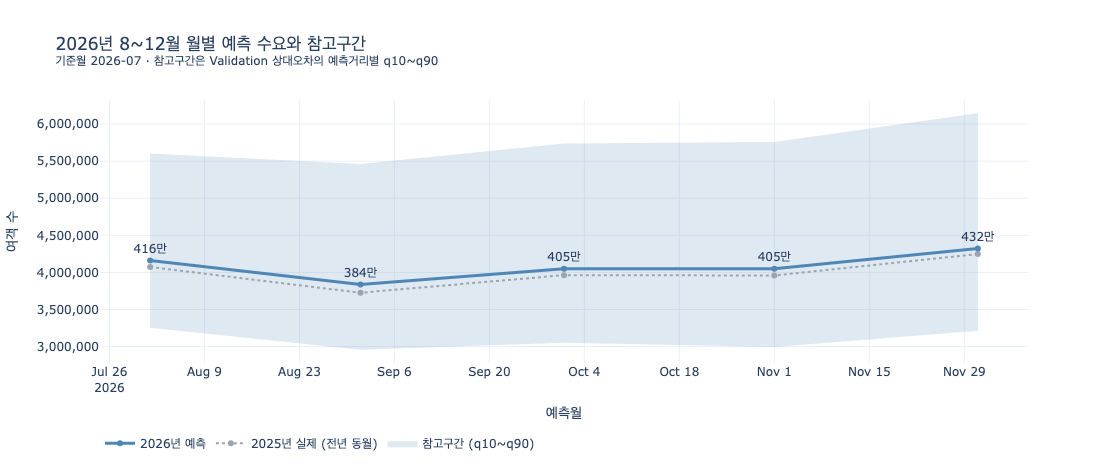

In [39]:
# 차트: 8~12월 월별 예측을 전년 동월 실적·참고구간과 함께 본다.
month_chart = feat_deploy.groupby('target_period').agg(
    전년실적=('seasonal_naive_pred', 'sum'), 예측=('pred_final', 'sum'),
    하한=('lo', 'sum'), 상한=('hi', 'sum')).reset_index()
month_chart['예측월'] = month_chart['target_period'].astype(str)

fig = go.Figure()
fig.add_trace(go.Scatter(x=month_chart['예측월'], y=month_chart['상한'],
                         mode='lines', line={'width': 0},
                         hoverinfo='skip', showlegend=False))
fig.add_trace(go.Scatter(x=month_chart['예측월'], y=month_chart['하한'],
                         name='참고구간 (q10~q90)', mode='lines',
                         line={'width': 0}, fill='tonexty',
                         fillcolor='rgba(79,134,181,0.18)'))
fig.add_trace(go.Scatter(x=month_chart['예측월'], y=month_chart['전년실적'],
                         name='2025년 실제 (전년 동월)', mode='lines+markers',
                         line={'color': '#9AA5B1', 'dash': 'dot'}))
fig.add_trace(go.Scatter(x=month_chart['예측월'], y=month_chart['예측'],
                         name='2026년 예측', mode='lines+markers+text',
                         line={'color': '#4F86B5', 'width': 3},
                         text=month_chart['예측'].map(lambda v: f'{v/1e4:,.0f}만'),
                         textposition='top center'))
fig.update_layout(
    title=('2026년 8~12월 월별 예측 수요와 참고구간'
           '<br><sup>기준월 2026-07 · 참고구간은 Validation 상대오차의 예측거리별 q10~q90</sup>'),
    xaxis_title='예측월', yaxis_title='여객 수', yaxis_tickformat=',',
    template=PLOTLY_TEMPLATE, height=470,
    legend={'orientation': 'h', 'y': -0.25})
fig.show(config={'displaylogo': False})


In [40]:
# 감소 예측의 분해: 최종예측 = B1(전년동월×성장계수) × (1 + Ridge 보정).
# 두 자릿수 감소가 성장계수와 Ridge 중 어디에서 왔는지 분리한다.
decomp = feat_deploy.groupby('dest').agg(
    전년동월합=('seasonal_naive_pred', 'sum'),
    B1=('b1_base', 'sum'),
    최종=('pred_final', 'sum'),
    성장계수=('growth_damped', 'first')).reset_index()
decomp['B1_증감률'] = decomp['B1'] / decomp['전년동월합'] - 1
decomp['최종_증감률'] = decomp['최종'] / decomp['전년동월합'] - 1
decomp['Ridge_기여'] = decomp['최종'] / decomp['B1'] - 1

# 규모가 큰 노선만 본다(작은 노선의 극단 증감률 배제).
big = decomp[decomp['전년동월합'] >= 300_000]
print('감소 예측 상위 (전년동월 합계 30만 명 이상)')
display(big.nsmallest(6, '최종_증감률').round(
    {'전년동월합': 0, 'B1': 0, '최종': 0, '성장계수': 4,
     'B1_증감률': 4, '최종_증감률': 4, 'Ridge_기여': 4}))

ratio = feat_deploy.assign(
    r=lambda d: d['pred_final'] / d['b1_base'] - 1).groupby('horizon')['r']
display(pd.DataFrame({'Ridge보정_중앙값': ratio.median(),
                      '하향보정_목적지비율': ratio.apply(lambda s: (s < 0).mean())}).round(4))
print('총계 기준 B1 %.0f명 -> 최종 %.0f명 (%+.0f명)' % (
    feat_deploy['b1_base'].sum(), feat_deploy['pred_final'].sum(),
    feat_deploy['pred_final'].sum() - feat_deploy['b1_base'].sum()))


감소 예측 상위 (전년동월 합계 30만 명 이상)


,dest,전년동월합,B1,최종,성장계수,B1_증감률,최종_증감률,Ridge_기여
16,다낭,657214.0,555693.0,490001.0,0.8455,-0.1545,-0.2544,-0.1182
54,방콕,639137.0,543678.0,481499.0,0.8506,-0.1494,-0.2466,-0.1144
8,나트랑캄란,477076.0,400272.0,360640.0,0.8390,-0.1610,-0.2441,-0.0990
40,마닐라,381895.0,363553.0,340948.0,0.9520,-0.0480,-0.1072,-0.0622
86,싱가폴,480922.0,476109.0,448249.0,0.9900,-0.0100,-0.0679,-0.0585
155,하노이,398269.0,401469.0,378117.0,1.0080,0.0080,-0.0506,-0.0582


,Ridge보정_중앙값,하향보정_목적지비율
horizon,,
1,-0.0380,0.6627
2,-0.0401,0.6331
3,-0.0420,0.6213
4,-0.0319,0.6036
5,-0.0234,0.5680


총계 기준 B1 21241512명 -> 최종 20416998명 (-824514명)


### 감소 예측은 어디에서 오는가

두 자릿수 감소로 예측된 노선은 **성장계수와 Ridge 보정이 같은 방향으로 겹친 구간**이다. 다낭을 예로 들면 성장계수 0.8455가 −15.4%를 만들고 Ridge 잔차보정이 −11.8%를 더해 최종 −25.4%가 된다.

두 요소의 성격이 다르므로 해석도 분리해야 한다.

- **성장계수**는 관측에서 나온다. 다낭의 2026년 5–7월 실제 수요는 전년 동기 대비 −23.1%였고(방콕 −22.5%), 성장계수는 이 관측을 담고 있다. 다만 h1–h5에서 상수이므로 **최근 3개월 상태가 다섯 달 내내 지속된다고 가정**한다.
- **Ridge 보정**은 Validation 잔차에서 학습한 값이다. 전체 목적지의 과반을 하향 보정하며 예측 거리별 중앙값은 −2.3%–−4.2%다. 앞 절에서 확인했듯 이 층은 Test 구간에서 오차를 키웠다.

따라서 **감소 방향은 실측에 근거하지만 −25%라는 크기는 지속 가정과 하향 보정에 의존한다.** 후보표에서 이 노선들을 신규 프로모션이 아닌 원인 진단 대상으로 분류한 근거는 방향이며, 감소 폭 자체를 목표 수치로 쓰지 않는다.


### 결과 해석과 결론

8월–12월 중심 예측은 각각 416만·384만·405만·405만·432만 명이며 합계는 약 **2,042만 명**이다. 참고구간 합계는 **1,547만–2,871만 명**으로, 반드시 포함된다는 보장은 아니다.

11·12월은 h4·h5이고 검증 반복도 적어 `저신뢰`다. 8–10월을 우선 활용하고 이후 월은 예약·좌석 자료가 쌓이면 갱신한다. 가격·좌석·마진이 없으므로 다음 절의 목적지 표는 후보 탐색용으로만 사용한다.

---

## 8. 최종 모델 B1+Ridge 기준 프로모션 후보표

목적지를 **예상 수요가 큰 기존 인기 목적지**와 **상위권 밖에서 수요 증가가 예상되는 목적지**로 나눠 본다.

기존 인기 목적지는 2026년 8월–12월 예상 여객으로 정렬한다. 떠오르는 목적지는 2025년 상위 20개를 제외하고 표본기간·증가 인원·증가 지속 월을 함께 확인한다. 이 표는 매출·ROI 순위가 아니다.

In [41]:
# 최종 B1+Ridge 후보표: 예측 + 성수월(계절지수) + 성장률 + 운항안정성 주석
ops = pd.read_sql(text('SELECT * FROM v_metric_operation_destination_monthly'), engine)
ops_recent = (ops[ops['operating_month'].astype(str).str.startswith('2025')]
              .groupby('destination_canonical_std')
              .agg(지연율=('status_delay_rate', 'mean'), 취소율=('cancellation_rate', 'mean')).reset_index())
di_deploy, pooled_deploy = fl.seasonal_index_asof(grids, pd.Period('2026-07', 'M'))
peak_month = lambda d: int(np.argmax(di_deploy.get(d, pooled_deploy))) + 1

aug_pred_by_dest = (feat_deploy[feat_deploy['target_period'] == pd.Period('2026-08', 'M')]
                    .set_index('dest')['pred_final'])

cand = (feat_deploy.groupby('dest')
        .agg(예측_8_12=('pred_final','sum'), 하한=('lo','sum'), 상한=('hi','sum'), 성장계수=('growth_damped','first'))
        .reset_index())
cand.insert(1, '예측_2026_08', cand['dest'].map(aug_pred_by_dest))
cand['성수월'] = cand['dest'].map(peak_month)
cand['sample_band'] = cand['dest'].map(profile.set_index('destination_canonical_std')['sample_band'])
cand = cand.merge(ops_recent, left_on='dest', right_on='destination_canonical_std', how='left').drop(columns='destination_canonical_std')
cand = cand.sort_values('예측_8_12', ascending=False).reset_index(drop=True)
display(cand.head(15).round({'예측_2026_08':0, '하한':0, '상한':0, '성장계수':3, '지연율':3, '취소율':3}))
print('주의: 가격·좌석·마진·예약·전환 데이터 부재 -> ROI·탑승률·매출·최적 할인율 산출 불가. 산출물은 타겟 후보 목적지·시기.')


,dest,예측_2026_08,예측_8_12,하한,상한,성장계수,성수월,sample_band,지연율,취소율
0,간사이,322610.0,1.854611e+06,1402725.0,2611867.0,1.195,12,ge36,0.245,0.000
1,도쿄나리타,279197.0,1.449787e+06,1098109.0,2039739.0,1.192,3,ge36,0.304,0.001
2,후쿠오카,216635.0,1.140694e+06,863846.0,1605080.0,1.115,12,ge36,0.218,0.000
3,타이페이,194312.0,9.932047e+05,752215.0,1397079.0,1.095,12,ge36,0.337,0.000
4,푸동,207311.0,9.747879e+05,739359.0,1369942.0,1.185,8,ge36,0.355,0.000
5,홍콩,151030.0,7.207436e+05,545807.0,1013079.0,1.097,12,ge36,0.356,0.001
6,도쿄하네다,106974.0,5.343776e+05,405084.0,751538.0,1.110,10,ge36,0.123,0.001
7,다낭,104231.0,4.900007e+05,371350.0,688659.0,0.846,1,ge36,0.304,0.000
8,방콕,87769.0,4.814991e+05,364170.0,677787.0,0.851,1,ge36,0.421,0.000
9,싱가폴,80645.0,4.482488e+05,339123.0,631064.0,0.990,12,ge36,0.376,0.000


주의: 가격·좌석·마진·예약·전환 데이터 부재 -> ROI·탑승률·매출·최적 할인율 산출 불가. 산출물은 타겟 후보 목적지·시기.


### 결과 해석: 어떤 목적지와 시기를 먼저 볼 것인가

`예측_2026_08`은 실제 8월 수요 공개 후 비교할 한 달 예측값이고, `예측_8_12`는 2026년 8월–12월 예상 여객 합계다. 성장계수 1.195는 최근 흐름이 전년보다 약 19.5% 높다는 뜻이다. `성수월`은 평년 최고 수요월, 지연율은 운영 위험 지표다.

**1차 검토: 연말 수요가 크고 성장도 양수인 목적지**

- 오사카 간사이는 185만 명, 성장계수 1.195, 성수월 12월로 규모와 성장 방향이 모두 강하다. 12월 수요를 겨냥해 10–11월부터 검토할 후보이다.
- 후쿠오카는 114만 명, 성장계수 1.115, 성수월 12월이며 지연율도 21.8%로 상대적으로 낮다.
- 타이베이와 홍콩도 각각 99만 명, 72만 명이며 성수월이 12월이다. 다만 지연율이 각각 33.7%, 35.6%이므로 좌석·운항 여유를 확인한 뒤 집행해야 한다.
- 삿포로는 43만 명으로 작지만 성수월 12월, 성장계수 1.082, 지연율 15.2%여서 겨울 테마 후보로 볼 수 있다.

**시기 대응형 후보**

- 상하이 푸둥과 베이징은 성수월이 8월이고 성장계수는 1.185, 1.199다. 8월 잔여 좌석을 확인한 단기 후보이며, 푸둥은 지연율 35.5%라 운영 확인이 필요하다.
- 도쿄 하네다는 성수월 10월, 성장계수 1.110, 지연율 12.3%로 9–10월 후보에 적합하다.
- 도쿄 나리타는 145만 명, 성장계수 1.192지만 성수월은 3월이다. 상시 수요 후보로 보되 연말 성수기 후보로 해석하지 않는다.

**우선순위를 낮춰 확인할 목적지**

다낭·방콕·나트랑 깜라인은 수요 규모는 크지만 성장계수가 1보다 낮아 공격적인 프로모션 1순위로 보기 어렵다. 가격 효과는 별도 가격·전환 데이터가 필요하다.

### 의사결정 결론

**연말 대형 후보는 오사카 간사이·후쿠오카**, 운영 확인 후보는 **타이베이·홍콩**, 겨울 테마는 **삿포로**, 10월은 **도쿄 하네다**다. 8월에는 상하이 푸둥·베이징을 단기 후보로 볼 수 있다.

이는 수요 관점의 검토 목록이다. 최종 집행에는 가격·좌석·예약률·마진·캠페인 비용을 추가해야 한다.

### 떠오르는 여행지

작은 노선의 높은 성장률이 과장되지 않도록 2025년 상위 20개를 제외하고 아래 조건을 적용한다.

- 과거 관측기간이 24개월 이상
- 2025년 8월–12월 실제수요가 3만 명 이상
- 2026년 같은 기간 예측수요가 5만 명 이상
- 최근 성장계수가 1보다 큼
- 다섯 달 중 최소 3개월에서 전년동월보다 높은 수요를 예측

통과한 목적지는 **예상 증가 인원** 순으로 정렬한다.

In [42]:
# 기존 인기권을 제외하고 규모·성장·지속성 조건을 통과한 떠오르는 목적지를 찾는다.
annual_2025 = (panel[panel['period'].between(
    pd.Period('2025-01', 'M'), pd.Period('2025-12', 'M'))]
    .groupby('dest')['passengers'].sum().sort_values(ascending=False))
popular_top20 = set(annual_2025.head(20).index)
popularity_rank = annual_2025.rank(method='min', ascending=False)

emerging = (feat_deploy.groupby('dest')
            .agg(전년동기_2025=('seasonal_naive_pred', 'sum'),
                 예측_2026_8_12=('pred_final', 'sum'),
                 성장계수=('growth_damped', 'first'))
            .reset_index())
emerging.insert(2, '예측_2026_08', emerging['dest'].map(aug_pred_by_dest))
growth_months = (feat_deploy.assign(
    전년동월보다_증가=lambda d: d['pred_final'] > d['seasonal_naive_pred'])
    .groupby('dest')['전년동월보다_증가'].sum())
emerging['예상증가인원'] = (
    emerging['예측_2026_8_12'] - emerging['전년동기_2025'])
emerging['예상증가율_%'] = np.where(
    emerging['전년동기_2025'] > 0,
    emerging['예상증가인원'] / emerging['전년동기_2025'] * 100, np.nan)
emerging['증가예상월수'] = emerging['dest'].map(growth_months).astype(int)
emerging['2025_인기순위'] = emerging['dest'].map(popularity_rank).astype('Int64')
emerging['sample_band'] = emerging['dest'].map(
    profile.set_index('destination_canonical_std')['sample_band'])
emerging['성수월'] = emerging['dest'].map(peak_month)
emerging = emerging.merge(
    ops_recent, left_on='dest', right_on='destination_canonical_std',
    how='left').drop(columns='destination_canonical_std')

emerging_candidates = (emerging[
    (~emerging['dest'].isin(popular_top20))
    & emerging['sample_band'].isin(['ge36', '24_35'])
    & (emerging['전년동기_2025'] >= 30_000)
    & (emerging['예측_2026_8_12'] >= 50_000)
    & (emerging['성장계수'] > 1.0)
    & (emerging['예상증가인원'] > 0)
    & (emerging['증가예상월수'] >= 3)
]
    .sort_values(['예상증가인원', '예상증가율_%'], ascending=False)
    .reset_index(drop=True))
display(emerging_candidates.head(12).round({
    '전년동기_2025': 0, '예측_2026_08': 0, '예측_2026_8_12': 0, '예상증가인원': 0,
    '예상증가율_%': 1, '성장계수': 3, '지연율': 3, '취소율': 3}))
print('떠오르는 여행지 후보 수:', len(emerging_candidates),
      '| 기존 인기권 제외 기준: 2025년 연간 여객 상위 20개')


,dest,전년동기_2025,예측_2026_08,예측_2026_8_12,성장계수,예상증가인원,예상증가율_%,증가예상월수,2025_인기순위,sample_band,성수월,지연율,취소율
0,카오슝,199517.0,47640.0,250427.0,1.268,50910.0,25.5,5,24,ge36,12,0.194,0.003
1,따이쭝,75478.0,21367.0,119289.0,1.469,43811.0,58.0,5,66,24_35,12,0.357,0.000
2,지난,70138.0,24051.0,108181.0,1.469,38043.0,54.2,5,70,ge36,8,0.183,0.002
3,광저우,184661.0,40235.0,214951.0,1.184,30290.0,16.4,5,26,ge36,10,0.218,0.000
4,대련,118530.0,36552.0,148768.0,1.247,30238.0,25.5,5,47,ge36,8,0.203,0.001
5,히로시마,50679.0,12382.0,76935.0,1.469,26256.0,51.8,5,81,ge36,12,0.105,0.000
6,시즈오카,47342.0,12809.0,72442.0,1.469,25100.0,53.0,5,87,ge36,12,0.261,0.000
7,시애틀,123676.0,32438.0,147010.0,1.199,23334.0,18.9,5,41,ge36,8,0.443,0.004
8,런던히드로,82101.0,24336.0,103503.0,1.248,21402.0,26.1,5,56,ge36,8,0.402,0.003
9,뱅쿠버,119928.0,32575.0,139720.0,1.177,19792.0,16.5,5,42,ge36,8,0.387,0.004


떠오르는 여행지 후보 수: 35 | 기존 인기권 제외 기준: 2025년 연간 여객 상위 20개


#### 결과 해석: 어떤 목적지가 떠오르고 있나

`예측_2026_08`은 실제 8월 수요 공개 후 비교할 한 달 예측값이다. `2025_인기순위`는 실제 여객 순위, `예상증가인원`은 2026년 예측과 2025년 동기 수요의 차이, `증가예상월수`는 증가가 예상된 월 수다. 총 35개 목적지가 통과했다.

- **가오슝**은 24위이며 8–12월 수요가 20.0만 명에서 25.0만 명으로 증가할 전망이다. 증가율 25.5%, 다섯 달 모두 증가, 지연율 19.4%로 가장 균형 잡힌 후보다.
- **타이중·지난**은 각각 4.4만 명, 3.8만 명 증가하고 증가율도 58.0%, 54.2%로 높다. 타이중은 관측기간이 짧고 지연율이 35.7%라 추가 확인이 필요하다.
- **광저우·다롄**은 기존 수요가 18.5만 명, 11.9만 명인 상태에서 약 3만 명씩 증가해 규모와 성장의 균형이 좋다.
- **히로시마·시즈오카**는 증가율이 51.8%, 53.0%지만 증가 인원은 약 2.6만 명, 2.5만 명이어서 지방도시 테마형 후보에 가깝다.
- 시애틀·런던 히드로·밴쿠버는 성장 후보지만 지연율이 38.7–44.3%여서 운항과 좌석을 먼저 확인해야 한다.

정리하자면 **가오슝**은 우선 집행할 주력 성장 프로모션 대상으로 추천한다. **지난·광저우·다롄**은 수요 규모와 증가폭이 함께 확인돼 좌석 연계 할인이나 상시 캠페인으로 확장하고, **타이중·히로시마·시즈오카**는 ‘떠오르는 지방도시’ 테마의 소규모 테스트 캠페인으로 반응을 확인한다.

이는 검색량·SNS 유행 순위가 아니라 **항공 여객수요 기준 성장 후보**다. 집행 전 좌석·가격·예약률을 확인해야 한다.

---

In [43]:
# Tableau용 최종 예측·후보·모델 성능 CSV 저장
import tableau_utils as tu

tableau_dir = ROOT / 'tableau'
tableau_dir.mkdir(exist_ok=True)

# 1) 목적지 × 예측월: 실제값 공개 후 같은 행에 사후 오차를 채울 수 있는 구조
forecast_export = feat_deploy[[
    'origin', 'target_period', 'horizon', 'dest', 'seasonal_naive_pred',
    'pred_final', 'lo', 'hi', 'growth_damped', 'seasonal_index_target',
    'seasonal_index_own', '검증WAPE', '저신뢰'
]].copy()
forecast_export = tu.add_destination_labels(forecast_export, 'dest')
forecast_export['예측기준일'] = forecast_export['origin'].dt.to_timestamp()
forecast_export['예측월'] = forecast_export['target_period'].dt.to_timestamp()
forecast_export['연도'] = forecast_export['target_period'].dt.year
forecast_export['월'] = forecast_export['target_period'].dt.month
forecast_export['2025_인기순위'] = forecast_export['dest'].map(popularity_rank).astype('Int64')
forecast_export['표본구간'] = forecast_export['dest'].map(
    profile.set_index('destination_canonical_std')['sample_band'])
forecast_export['성수월'] = forecast_export['dest'].map(peak_month)
forecast_export['후보구분'] = np.select(
    [forecast_export['dest'].isin(popular_top20),
     forecast_export['dest'].isin(set(emerging_candidates['dest']))],
    ['기존 인기', '성장 후보'], default='기타 모델링 목적지')
forecast_export['신뢰등급'] = np.where(forecast_export['저신뢰'], '저신뢰', '일반')
forecast_export['예상증가인원'] = (
    forecast_export['pred_final'] - forecast_export['seasonal_naive_pred'])
forecast_export['예상증가율'] = np.where(
    forecast_export['seasonal_naive_pred'] > 0,
    forecast_export['예상증가인원'] / forecast_export['seasonal_naive_pred'], np.nan)
forecast_export['월예측비중'] = forecast_export['pred_final'] / forecast_export.groupby(
    'target_period')['pred_final'].transform('sum')
forecast_export = forecast_export.merge(
    ops_recent.rename(columns={'destination_canonical_std': 'dest',
                               '지연율': '2025_상태지연율', '취소율': '2025_취소율'}),
    on='dest', how='left', validate='m:1')
forecast_export['실제수요'] = np.nan
forecast_export['절대오차'] = np.nan
forecast_export['APE'] = np.nan
forecast_export = forecast_export.rename(columns={
    'seasonal_naive_pred': '전년동월실제수요', 'pred_final': '예측수요',
    'lo': '예측하한', 'hi': '예측상한', 'growth_damped': '성장계수',
    'seasonal_index_target': '계절지수', 'seasonal_index_own': '계절지수_자체산출여부'
})
forecast_export = forecast_export[[
    '예측기준일', '예측월', '연도', '월', 'horizon', '목적지_DB', '목적지', '국가', '지역',
    '전년동월실제수요', '예측수요', '예측하한', '예측상한', '월예측비중',
    '예상증가인원', '예상증가율', '성장계수', '계절지수', '계절지수_자체산출여부',
    '검증WAPE', '신뢰등급', '2025_인기순위', '후보구분', '표본구간', '성수월',
    '2025_상태지연율', '2025_취소율', '실제수요', '절대오차', 'APE'
]].sort_values(['예측월', '예측수요'], ascending=[True, False])

# 2) 후보 목적지 1행: 기존 인기 상위 20개 + 성장 후보 35개
promo_export = emerging.merge(cand[['dest', '하한', '상한']], on='dest', how='left', validate='1:1')
promo_export = promo_export[
    promo_export['dest'].isin(popular_top20 | set(emerging_candidates['dest']))].copy()
promo_export['후보구분'] = np.where(
    promo_export['dest'].isin(popular_top20), '기존 인기', '성장 후보')
promo_export['추천유형'] = promo_export['dest'].map({
    '카오슝': '주력 성장', '지난': '확장형', '광저우': '확장형', '대련': '확장형',
    '따이쭝': '탐색형', '히로시마': '탐색형', '시즈오카': '탐색형'
}).fillna(promo_export['후보구분'])
promo_export = tu.add_destination_labels(promo_export, 'dest')
promo_export['예상증가율'] = promo_export['예상증가율_%'] / 100
promo_export = promo_export.rename(columns={
    '전년동기_2025': '2025_8_12_실제수요', '예측_2026_08': '2026_08_예측수요',
    '예측_2026_8_12': '2026_8_12_예측수요', '하한': '2026_8_12_하한',
    '상한': '2026_8_12_상한', '지연율': '2025_상태지연율', '취소율': '2025_취소율',
    'sample_band': '표본구간'
})
promo_export = promo_export[[
    '후보구분', '추천유형', '목적지_DB', '목적지', '국가', '지역', '2025_인기순위',
    '2025_8_12_실제수요', '2026_08_예측수요', '2026_8_12_예측수요',
    '2026_8_12_하한', '2026_8_12_상한', '예상증가인원', '예상증가율',
    '증가예상월수', '성장계수', '성수월', '표본구간', '2025_상태지연율', '2025_취소율'
]].sort_values(['후보구분', '2026_8_12_예측수요'], ascending=[True, False])

# 3) Validation·Test 성능: 전체와 최종 모델의 h1~h5를 같은 long 구조로 저장
performance_rows = [
    {'평가구간': 'Validation', '모델': 'B0 최근 3개월 평균', '예측거리': '전체',
     'WAPE': b0_summary.loc['최근평균', 'WAPE'], '순편향': b0_summary.loc['최근평균', '순편향']},
    {'평가구간': 'Validation', '모델': 'B0 전년동월', '예측거리': '전체',
     'WAPE': b0_summary.loc['전년동월', 'WAPE'], '순편향': b0_summary.loc['전년동월', '순편향']},
    {'평가구간': 'Validation', '모델': 'B1 계절지수×수준', '예측거리': '전체',
     'WAPE': b1_summary.loc['계절지수×수준', 'WAPE'], '순편향': b1_summary.loc['계절지수×수준', '순편향']},
]
for row in b2_comparison.itertuples(index=False):
    performance_rows.append({'평가구간': 'Validation', '모델': row.모델, '예측거리': '전체',
                             'WAPE': row.WAPE, '순편향': row.순편향})
for h, wape_value in b15v2_by_h.items():
    part = b15v2[b15v2['horizon'] == h]
    performance_rows.append({'평가구간': 'Validation', '모델': 'B1+Ridge 잔차보정',
                             '예측거리': f'h{h}', 'WAPE': wape_value,
                             '순편향': (part['pred_b15v2'].sum() - part['target_passengers'].sum())
                                     / part['target_passengers'].sum()})
performance_rows.append({'평가구간': 'Test', '모델': FINAL_TEST_MODEL, '예측거리': '전체',
                         'WAPE': final_test_summary.loc[0, 'WAPE'],
                         '순편향': final_test_summary.loc[0, '순편향']})
for h, part in final_test.groupby('horizon'):
    performance_rows.append({'평가구간': 'Test', '모델': FINAL_TEST_MODEL,
                             '예측거리': f'h{h}', 'WAPE': _W(part, 'pred_final'),
                             '순편향': (part['pred_final'].sum() - part['target_passengers'].sum())
                                     / part['target_passengers'].sum()})
model_performance_export = pd.DataFrame(performance_rows)
model_performance_export['최종채택여부'] = (
    model_performance_export['모델'] == FINAL_TEST_MODEL)

assert len(forecast_export) == len(universe) * len(fl.HORIZONS)
assert not forecast_export.duplicated(['예측월', '목적지_DB']).any()
assert np.isclose(forecast_export['예측수요'].sum(), feat_deploy['pred_final'].sum())
assert len(promo_export) == len(popular_top20) + len(emerging_candidates)
assert model_performance_export.query("평가구간 == 'Test' and 예측거리 == '전체'").shape[0] == 1

for export_df, filename in [
    (forecast_export, 'forecast_destination_monthly.csv'),
    (promo_export, 'promotion_candidates.csv'),
    (model_performance_export, 'model_performance.csv'),
]:
    export_df.to_csv(tableau_dir / filename, index=False, encoding='utf-8-sig', date_format='%Y-%m-%d')
    print(f'{filename}: {len(export_df):,}행 × {export_df.shape[1]}열')
print('Tableau 예측 데이터 검증 통과 — 키 유일성·목적지 수·예측 합계 일치')


forecast_destination_monthly.csv: 845행 × 30열
promotion_candidates.csv: 55행 × 20열
model_performance.csv: 19행 × 6열
Tableau 예측 데이터 검증 통과 — 키 유일성·목적지 수·예측 합계 일치


### 대륙 단위 관점과 쇠퇴 주의군

앞의 후보표는 목적지 단위다. 여기서는 같은 예측을 대륙으로 묶어 어느 권역이 크고 어디가 식는지 본다. 규모는 아시아 편중이 뚜렷하므로, 성장 방향은 전년 동월 대비 성장률로 함께 확인한다.

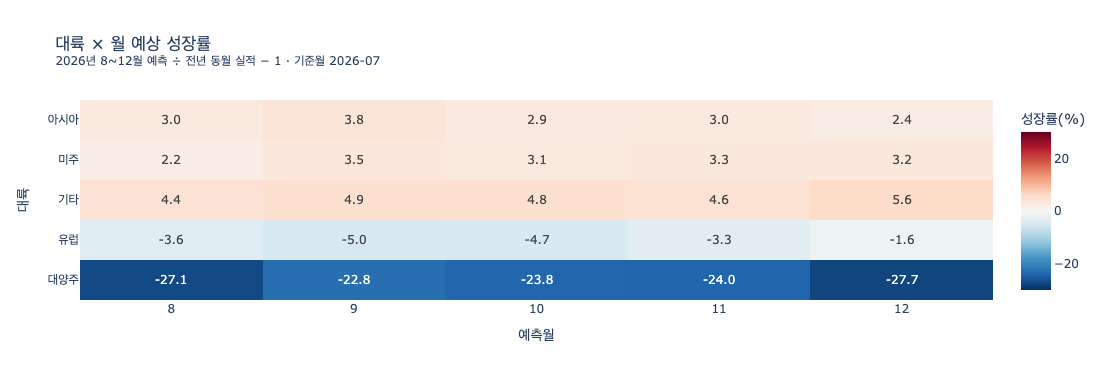

월,8,9,10,11,12
대륙,,,,,
아시아,3.0,3.8,2.9,3.0,2.4
미주,2.2,3.5,3.1,3.3,3.2
기타,4.4,4.9,4.8,4.6,5.6
유럽,-3.6,-5.0,-4.7,-3.3,-1.6
대양주,-27.1,-22.8,-23.8,-24.0,-27.7


In [44]:
# 대륙 단위 관점: 목적지 예측을 대륙으로 묶어 성장 모멘텀을 확인한다.
_cont = {'동북아': '아시아', '동남아': '아시아', '남아시아': '아시아', '중앙아시아': '아시아',
         '유럽': '유럽', '미주': '미주', '대양주': '대양주'}
fc = forecast_export.copy()
fc['대륙'] = fc['지역'].map(_cont).fillna('기타')

# 대륙 x 월 예상 성장률(%) = 예측수요 / 전년동월실제수요 - 1
cm = fc.groupby(['대륙', '월']).agg(
    예측=('예측수요', 'sum'), 전년=('전년동월실제수요', 'sum')).reset_index()
cm['성장률_%'] = (cm['예측'] / cm['전년'] - 1) * 100
cont_growth = cm.pivot(index='대륙', columns='월', values='성장률_%').round(1)
cont_growth = cont_growth.reindex(['아시아', '미주', '기타', '유럽', '대양주'])

fig = px.imshow(
    cont_growth, text_auto='.1f', aspect='auto',
    color_continuous_scale='RdBu_r', zmin=-30, zmax=30,
    labels={'x': '예측월', 'y': '대륙', 'color': '성장률(%)'},
    title=('대륙 × 월 예상 성장률'
           '<br><sup>2026년 8~12월 예측 ÷ 전년 동월 실적 − 1 · 기준월 2026-07</sup>'))
fig.update_layout(template=PLOTLY_TEMPLATE, height=380)
fig.show(config={'displaylogo': False})
display(cont_growth)


In [45]:
# 대륙별 8~12월 예측 규모와 성장률. 규모는 아시아에 쏠려 있으므로 방향과 함께 본다.
ct = fc.groupby('대륙').agg(
    예측_8_12=('예측수요', 'sum'), 전년_8_12=('전년동월실제수요', 'sum'))
ct['성장률_%'] = (ct['예측_8_12'] / ct['전년_8_12'] - 1) * 100
display(ct.sort_values('예측_8_12', ascending=False).round(
    {'예측_8_12': 0, '전년_8_12': 0, '성장률_%': 1}))


,예측_8_12,전년_8_12,성장률_%
대륙,,,
아시아,16738336.0,16250618.0,3.0
기타,1420352.0,1354830.0,4.8
미주,1255796.0,1218860.0,3.0
유럽,661065.0,686701.0,-3.7
대양주,341448.0,456983.0,-25.3


In [46]:
# 쇠퇴 주의군: 기존 인기(2025 상위 20)인데 8~12월 예측이 전년보다 감소하는 목적지
dec = (fc[fc['후보구분'] == '기존 인기']
       .groupby(['목적지', '지역']).agg(
           예측_8_12=('예측수요', 'sum'), 전년_8_12=('전년동월실제수요', 'sum')).reset_index())
dec['증가율_%'] = (dec['예측_8_12'] / dec['전년_8_12'] - 1) * 100
dec = dec[dec['증가율_%'] < 0].sort_values('증가율_%')
print('쇠퇴 주의군 — 기존 인기인데 전년 대비 감소 예측')
display(dec.round({'예측_8_12': 0, '증가율_%': 1}))


쇠퇴 주의군 — 기존 인기인데 전년 대비 감소 예측


,목적지,지역,예측_8_12,전년_8_12,증가율_%
2,다낭,동남아,490001.0,657214.0,-25.4
7,방콕,동남아,481499.0,639137.0,-24.7
1,나트랑 깜라인,동남아,360640.0,477076.0,-24.4
6,마닐라,동남아,340948.0,381895.0,-10.7
11,싱가포르,동남아,448249.0,480922.0,-6.8
5,로스앤젤레스,미주,240466.0,254362.0,-5.5
16,하노이,동남아,378117.0,398269.0,-5.1
17,호치민,동남아,352996.0,365098.0,-3.3
14,칭다오,동북아,400038.0,400517.0,-0.1


#### 결과 해석

- 규모는 아시아가 8~12월 예측의 대부분(약 1,670만 명)을 차지한다. 기타·미주·유럽·대양주를 모두 더해도 아시아의 약 1/4에 그친다.
- 성장 방향은 권역별로 갈린다. 아시아 약 +3%, 미주 +2-3%, 기타 +4-5%가 성장하는 반면 유럽은 −3-−5%, 대양주는 −22-−28%로 역성장이 예측된다. 다만 대양주·기타는 규모가 작아 성장률 변동이 크므로 방향만 참고한다.
- 쇠퇴 주의군: 2025년 상위 20위 기존 인기 목적지 중 다낭(−25.4%)·방콕(−24.7%)·나트랑 깜라인(−24.4%)·마닐라(−10.7%)가 두 자릿수 감소로 예측된다. 모두 동남아 노선이다. 싱가포르·하노이·호치민, 그리고 로스앤젤레스도 소폭 감소한다.
- 이들은 공격적 신규 프로모션보다 가격·경쟁·좌석 공급을 먼저 진단하고 이탈 방어(리텐션) 관점으로 접근하는 편이 맞다. 실제 수요 이동인지 예측 모델의 보수적 편향(Test 순편향 −3.8%)인지는 실적으로 재확인한다.

---

## 9. 종합 결론

### 종합 인사이트

- 단순 전년동월 B0의 Validation WAPE는 14.09%, 성장계수를 더한 B1은 11.84%, 최근 오차를 보정한 **B1+Ridge는 11.47%** 였다. 복잡한 트리보다 전년동월의 계절성을 유지하면서 최근 오차만 작게 보정하는 방식이 가장 안정적이었다.
- 미사용 2026년 Test에서 WAPE는 **13.32%**, 순편향은 −3.82%였다. 실제수요를 조금 낮게 보는 경향은 있었지만 Validation에서 고른 모델이 새로운 기간에서도 큰 붕괴 없이 유지됐다.
- 2026년 8–12월 중심 예측은 416만·384만·405만·405만·432만 명으로, 합계는 약 **2,042만 명**이다. 12월 수요가 가장 높지만 11·12월은 h4·h5라 8–10월보다 불확실하다.
- 기존 인기 목적지에서는 **오사카 간사이·후쿠오카**가 연말 주력 후보이고, **도쿄 하네다**는 10월, **삿포로**는 겨울 테마에 적합하다. 타이베이·홍콩은 수요가 크지만 상태 지연율을 함께 확인해야 한다.
- 성장 목적지에서는 **가오슝**이 규모·증가 지속성·운영 지표가 가장 균형적이다. 지난·광저우·다롄은 수요 규모를 동반한 확장형 후보, 타이중·히로시마·시즈오카는 높은 증가율을 활용할 탐색형 후보로 구분한다.
- 대륙 단위로는 아시아·미주·기타가 성장하지만 유럽·대양주는 역성장이 예측된다. 특히 기존 인기 동남아 노선(다낭·방콕·나트랑·마닐라)이 두 자릿수 감소로 나타나, 규모 상위권이라도 성장이 꺾이는 구간은 신규 프로모션보다 원인 진단과 이탈 방어가 우선이다.

### 액션 아이템

1. **8월 단기 대응**: 상하이 푸둥·베이징의 잔여 좌석과 가격을 확인해 단기 캠페인 여부를 결정한다.
2. **9–10월 집행**: 도쿄 하네다를 시기 대응 후보로 운영하고, 오사카 간사이·후쿠오카·삿포로의 연말 캠페인을 준비한다.
3. **성장 목적지 운영**: 가오슝은 주력 성장 캠페인으로 검토하고, 지난·광저우·다롄은 좌석 연계형 캠페인, 타이중·히로시마·시즈오카는 테마형 소규모 테스트로 반응을 확인한다.
4. **SNS 홍보 테스트**: 오사카 간사이·후쿠오카·삿포로는 계절·가격 중심의 전환형 소재를 사용한다. 타이중·히로시마·시즈오카는 ‘새롭게 떠오르는 지방도시’ 숏폼·여행코스 콘텐츠를 소규모로 집행한 뒤 클릭률·저장률·예약 전환이 좋은 목적지만 확대한다.
5. **예측 갱신**: 11–12월은 예약·좌석 자료가 쌓이는 시점에 다시 예측하고, 가격·예약률·마진·상태 지연율을 결합해 최종 우선순위를 확정한다.
6. **쇠퇴 방어**: 다낭·방콕·나트랑 등 감소 예측 동남아 노선은 가격·경쟁·좌석 공급을 진단한 뒤 리텐션 중심으로 대응하고, 실제 수요 이동 여부를 실적으로 재확인한다.

### 한계

수요 데이터만 사용했으므로 매출·ROI·할인율과 프로모션의 인과효과는 판단할 수 없다. 기록이 짧은 목적지와 먼 예측월은 오차가 더 클 수 있다.